In [1]:
import sys
from pathlib import Path

project_root = Path.cwd().parents[1]  # importing functions from other folders

sys.path.insert(0, str(project_root))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import os
from _data.data_utils import read_in
from _fitting.fitting_utils import abbrev_stat
# from _fitting.fitting_utils import hist_plot, CI_plot, CI_plot_alt, CI_plot_both, plot_posteriors_side_by_side, plot_spline_Bknots
import pymc as pm
import pymc.math as pmm
import arviz as az
from patsy import dmatrix
import nutpie
import time
from IPython.display import display
from pymc.variational.callbacks import CheckParametersConvergence
import io
import base64
import re
import pytensor.tensor as pt
from pytensor.gradient import disconnected_grad
from scipy.sparse.linalg import eigsh
from matplotlib.colors import Normalize, TwoSlopeNorm, to_rgba

az.style.use("arviz-darkgrid")

if '___laptop' in os.listdir('../../'):

    # laptop folder
    folder = "../../../_data/p-dengue/"
elif '___server' in os.listdir('../../'):

    # server folder
    folder = "../../../../../../data/lucaratzinger_data/p_dengue/"

%matplotlib inline
import seaborn as sns

import warnings
warnings.filterwarnings("ignore", category=RuntimeWarning)

In [2]:
model_fits_folder = os.path.join(folder, "model_fits/")
#run_folders = ["a2_201601_201912[smooth_s1|6_selection]"]
run_folders = ["a2_201601_201912[smooth_exact_s1|6_selection]", "a2_201601_201912[smooth_exact_s1|6_selection_othervals1]"]

---

In [3]:
data_settings = {'admin':2, 'max_lag':6, 'start_year':2016, 'start_month':1, 'end_year':2019, 'end_month':12}
_data = read_in(folder, **data_settings, standardise=True, dropna=True, celsius=True, tp_log=True)
statistics = _data.columns.tolist()
# that start with t2m, rh, tp
statistics = [name for name in statistics if name.startswith(('t2m','rh','tp'))]
# that contains 'pop_weighted'
statistics = [name for name in statistics if 'pop_weighted' in name]
# if it contains 'tp' then it should contain 'log('
statistics = [name for name in statistics if not (name.startswith('tp') and 'log(' not in name)]
lags = [0, 1, 3, 5]
statistics = [stat for stat in statistics if any(f"({lag})" in stat for lag in lags)]
statistics.sort()

---

In [2]:
def loo_compare(model_fits_dir, run_folders, p=None, num_knots=None, stat_name=None, diff_quantile=0.95, pointwise=False):
    def parse_name(name):
        p_match = re.search(r'p=([\d.]+)', name)
        k_match = re.search(r'__knots\((\d+)', name)
        # s_match = re.search(r'std=(True|False)', name)
        stat_match = re.search(r'\[([a-zA-Z0-9_()]+)\]', name)
        return {
            'p': float(p_match.group(1)) if p_match else None,
            'num_knots': int(k_match.group(1)) if k_match else None,
            # 'std': s_match.group(1) == 'True' if s_match else None,
            'stat_name': stat_match.group(1) if stat_match else None,
        }

    p_set = set(p) if p is not None else None
    k_set = set(num_knots) if num_knots is not None else None
    # std_set = set(std) if std is not None else None
    stat_set = set(stat_name) if stat_name is not None else None

    rows = {}
    for run in run_folders:
        metrics_dir = os.path.join(model_fits_dir, run, 'metrics')
        if not os.path.isdir(metrics_dir):
            continue
        for fname in os.listdir(metrics_dir):
            if not fname.endswith('.npz'):
                continue
            meta = parse_name(fname)
            if p_set is not None and meta['p'] not in p_set:
                continue
            if k_set is not None and meta['num_knots'] not in k_set:
                continue
            # if std_set is not None and meta['std'] not in std_set:
                # continue
            if stat_set is not None and meta['stat_name'] not in stat_set:
                continue
            metrics = np.load(os.path.join(metrics_dir, fname))
            loo_pw = metrics['loo_pointwise']
            pareto_k = metrics['pareto_k']
            n = len(loo_pw)
            rows[fname[:-4]] = {
                'stat_name': meta['stat_name'],
                'p': meta['p'],
                'num_knots': meta['num_knots'],
                'elpd_loo': loo_pw.sum(),
                'safe_elpd_loo': loo_pw[pareto_k <= 0.7].sum(),
                'se': (n * loo_pw.var()) ** 0.5,
                'pointwise': loo_pw,
                'pareto_k': pareto_k,
                'n_bad_k': (pareto_k > 0.7).sum(),
            }

    if not rows:
        raise ValueError("No models matched the given filters.")
    
    #df = pd.DataFrame(rows).T.sort_values('elpd_loo', ascending=False)
    df = pd.DataFrame(rows).T.sort_values('safe_elpd_loo', ascending=False)
    best_pw = df['pointwise'].iloc[0]
    best_pareto_k = df['pareto_k'].iloc[0]
    elpd_diff, dse = [], []
    elpd_diff_quantile = []
    for i in range(len(df)):
        pw = df['pointwise'].iloc[i]
        pareto_k = df['pareto_k'].iloc[i]
        diff_pw = best_pw - pw
        diff_pw = diff_pw[(pareto_k <= 0.7) & (best_pareto_k <= 0.7)]
        elpd_diff.append(diff_pw.sum())
        dse.append(np.std(diff_pw) * np.sqrt(len(diff_pw)))
        elpd_diff_quantile.append(np.percentile(diff_pw, (1 - diff_quantile) * 100))
    df['elpd_diff'] = elpd_diff
    df['dse'] = dse
    df['elpd_diff_quantile'] = elpd_diff_quantile
    if not pointwise:
        df = df.drop(columns='pointwise')
    return df

In [3]:
def loo_compare_profiles(model_fits_dir, run_folders, profiles, diff_quantile=0.95, pointwise=False):
    profiles_tuples = [(abbrev_stat(s), c[0][0], c[0][1]) for s, c in profiles.items()]
    def parse_name(name):
        p_match = re.search(r'p=([\d.]+)', name)
        k_match = re.search(r'__knots\((\d+)', name)
        # s_match = re.search(r'std=(True|False)', name)
        stat_match = re.search(r'\[([a-zA-Z0-9_()]+)\]', name)
        return {
            'p': float(p_match.group(1)) if p_match else None,
            'num_knots': int(k_match.group(1)) if k_match else None,
            # 'std': s_match.group(1) == 'True' if s_match else None,
            'stat_name': stat_match.group(1) if stat_match else None,
        }

    rows = {}
    for run in run_folders:
        metrics_dir = os.path.join(model_fits_dir, run, 'metrics')
        if not os.path.isdir(metrics_dir):
            continue
        for fname in os.listdir(metrics_dir):
            if not fname.endswith('.npz'):
                continue
            meta = parse_name(fname)
            if (meta['stat_name'], meta['p'], meta['num_knots']) not in profiles_tuples:
                continue
            metrics = np.load(os.path.join(metrics_dir, fname))
            loo_pw = metrics['loo_pointwise']
            pareto_k = metrics['pareto_k']
            n = len(loo_pw)
            rows[fname[:-4]] = {
                'stat_name': meta['stat_name'],
                'p': meta['p'],
                'num_knots': meta['num_knots'],
                'elpd_loo': loo_pw.sum(),
                'safe_elpd_loo': loo_pw[pareto_k <= 0.7].sum(),
                'se': (n * loo_pw.var()) ** 0.5,
                'pointwise': loo_pw,
                'pareto_k': pareto_k,
                'n_bad_k': (pareto_k > 0.7).sum(),
            }

    if not rows:
        raise ValueError("No models matched the given filters.")
    
    #df = pd.DataFrame(rows).T.sort_values('elpd_loo', ascending=False)
    df = pd.DataFrame(rows).T.sort_values('safe_elpd_loo', ascending=False)
    best_pw = df['pointwise'].iloc[0]
    best_pareto_k = df['pareto_k'].iloc[0]

    safe_elpd_diff, safe_dse = [], []
    elpd_diff, dse = [], []

    safe_elpd_diff_quantile = []
    elpd_diff_quantile = []
    for i in range(len(df)):
        pw = df['pointwise'].iloc[i]
        pareto_k = df['pareto_k'].iloc[i]
        diff_pw = best_pw - pw
        safe_diff_pw = diff_pw[(pareto_k <= 0.7) & (best_pareto_k <= 0.7)]

        elpd_diff.append(diff_pw.sum())
        safe_elpd_diff.append(safe_diff_pw.sum())

        dse.append(np.std(diff_pw) * np.sqrt(len(diff_pw)))
        safe_dse.append(np.std(safe_diff_pw) * np.sqrt(len(safe_diff_pw)))

        elpd_diff_quantile.append(np.percentile(diff_pw, (1 - diff_quantile) * 100))
        safe_elpd_diff_quantile.append(np.percentile(safe_diff_pw, (1 - diff_quantile) * 100))

    df['elpd_diff'] = elpd_diff
    df['dse'] = dse
    df['safe_elpd_diff'] = safe_elpd_diff
    df['safe_dse'] = safe_dse

    df['elpd_diff_quantile'] = elpd_diff_quantile
    df['safe_elpd_diff_quantile'] = safe_elpd_diff_quantile
    
    if not pointwise:
        df = df.drop(columns='pointwise')
    return df

In [4]:
def loo_compare_models(model_fits_dir, run_folders, models, diff_quantile=0.95, pointwise=False):

    rows = {}
    for run in run_folders:
        metrics_dir = os.path.join(model_fits_dir, run, 'metrics')
        if not os.path.isdir(metrics_dir):
            continue
        for fname in os.listdir(metrics_dir):
            if not fname.endswith('.npz'):
                continue
            fmodel = fname[9:-5]
            if len(models) > 0 and fmodel not in models:
                continue
            metrics = np.load(os.path.join(metrics_dir, fname))
            loo_pw = metrics['loo_pointwise']
            pareto_k = metrics['pareto_k']
            n = len(loo_pw)
            rows[fname[:-4]] = {
                'model': fmodel,
                'elpd_loo': loo_pw.sum(),
                'safe_elpd_loo': loo_pw[pareto_k <= 0.7].sum(),
                'se': (n * loo_pw.var()) ** 0.5,
                'pointwise': loo_pw,
                'pareto_k': pareto_k,
                'n_bad_k': (pareto_k > 0.7).sum(),
            }

    if not rows:
        raise ValueError("No models matched the given filters.")
    
    #df = pd.DataFrame(rows).T.sort_values('elpd_loo', ascending=False)
    df = pd.DataFrame(rows).T.sort_values('safe_elpd_loo', ascending=False)
    best_pw = df['pointwise'].iloc[0]
    best_pareto_k = df['pareto_k'].iloc[0]

    safe_elpd_diff, safe_dse = [], []
    elpd_diff, dse = [], []

    safe_elpd_diff_quantile = []
    elpd_diff_quantile = []
    for i in range(len(df)):
        pw = df['pointwise'].iloc[i]
        pareto_k = df['pareto_k'].iloc[i]
        diff_pw = best_pw - pw
        safe_diff_pw = diff_pw[(pareto_k <= 0.7) & (best_pareto_k <= 0.7)]

        elpd_diff.append(diff_pw.sum())
        safe_elpd_diff.append(safe_diff_pw.sum())

        dse.append(np.std(diff_pw) * np.sqrt(len(diff_pw)))
        safe_dse.append(np.std(safe_diff_pw) * np.sqrt(len(safe_diff_pw)))

        elpd_diff_quantile.append(np.percentile(diff_pw, (1 - diff_quantile) * 100))
        safe_elpd_diff_quantile.append(np.percentile(safe_diff_pw, (1 - diff_quantile) * 100))

    df['elpd_diff'] = elpd_diff
    df['dse'] = dse
    df['safe_elpd_diff'] = safe_elpd_diff
    df['safe_dse'] = safe_dse

    df['elpd_diff_quantile'] = elpd_diff_quantile
    df['safe_elpd_diff_quantile'] = safe_elpd_diff_quantile
    
    if not pointwise:
        df = df.drop(columns='pointwise')
    return df

In [12]:
# '20_smooth_exact_simple_adjusted_greedy_1'
data_settings = {'admin':2, 'max_lag':6, 'start_year':2016, 'start_month':1, 'end_year':2019, 'end_month':12}
_data = read_in(folder, **data_settings, standardise=True, dropna=True, celsius=True, tp_log=True)
statistics = _data.columns.tolist()
# that start with t2m, rh, tp
statistics = [name for name in statistics if name.startswith(('t2m','rh','tp'))]
# that contains 'pop_weighted'
statistics = [name for name in statistics if 'pop_weighted' in name]
# if it contains 'tp' then it should contain 'log('
statistics = [name for name in statistics if not (name.startswith('tp') and 'log(' not in name)]
lags = [0, 1, 2, 3, 4, 5, 6]
statistics = [stat for stat in statistics if any(f"({lag})" in stat for lag in lags)]
statistics.sort()

# '20_smooth_exact_simple_adjusted_greedy_1'
model_fits_folder = os.path.join(folder, "model_fits/")
run_folders = ["a2_201601_201912[20_smooth_exact_simple_adjusted_greedy_1]"]

df_g1 = loo_compare_models(model_fits_folder, run_folders, models=[], diff_quantile=0.90, pointwise=True)
df_g1 = df_g1[['model', 'elpd_loo', 'safe_elpd_loo','elpd_diff', 'safe_elpd_diff', 'dse', 'safe_dse', 'elpd_diff_quantile', 'n_bad_k']].sort_values('safe_elpd_loo', ascending=False)
df_g1.set_index('model', inplace=True)
df = df_g1

In [36]:
# '20_smooth_exact_simple_adjusted_greedy_2'
data_settings = {'admin':2, 'max_lag':6, 'start_year':2016, 'start_month':1, 'end_year':2019, 'end_month':12}
_data = read_in(folder, **data_settings, standardise=True, dropna=True, celsius=True, tp_log=True)
statistics = _data.columns.tolist()
# that start with t2m, rh, tp
statistics = [name for name in statistics if name.startswith(('t2m','rh','tp'))]
# that contains 'pop_weighted'
statistics = [name for name in statistics if 'pop_weighted' in name]
# if it contains 'tp' then it should contain 'log('
statistics = [name for name in statistics if not (name.startswith('tp') and 'log(' not in name)]
lags = [0, 1, 2, 3, 4, 5, 6]
statistics = [stat for stat in statistics if any(f"({lag})" in stat for lag in lags)]
statistics.sort()

# '20_smooth_exact_simple_adjusted_greedy_2'
model_fits_folder = os.path.join(folder, "model_fits/")
run_folders = ["a2_201601_201912[20_smooth_exact_simple_adjusted_greedy_1]", "a2_201601_201912[20_smooth_exact_simple_adjusted_greedy_2]"]

df_g2 = loo_compare_models(model_fits_folder, run_folders, models=[], diff_quantile=0.90, pointwise=True)
df_g2 = df_g2[['model', 'elpd_loo', 'safe_elpd_loo','elpd_diff', 'safe_elpd_diff', 'dse', 'safe_dse', 'elpd_diff_quantile', 'n_bad_k']].sort_values('safe_elpd_loo', ascending=False)
df_g2.set_index('model', inplace=True)
df_g2['n_vars'] = df_g2.index.str.count('p=')
df = df_g2

In [5]:
# '20_smooth_exact_simple_adjusted_greedy_3'
data_settings = {'admin':2, 'max_lag':6, 'start_year':2016, 'start_month':1, 'end_year':2019, 'end_month':12}
_data = read_in(folder, **data_settings, standardise=True, dropna=True, celsius=True, tp_log=True)
statistics = _data.columns.tolist()
# that start with t2m, rh, tp
statistics = [name for name in statistics if name.startswith(('t2m','rh','tp'))]
# that contains 'pop_weighted'
statistics = [name for name in statistics if 'pop_weighted' in name]
# if it contains 'tp' then it should contain 'log('
statistics = [name for name in statistics if not (name.startswith('tp') and 'log(' not in name)]
lags = [0, 1, 2, 3, 4, 5, 6]
statistics = [stat for stat in statistics if any(f"({lag})" in stat for lag in lags)]
statistics.sort()

# '20_smooth_exact_simple_adjusted_greedy_3'
model_fits_folder = os.path.join(folder, "model_fits/")
run_folders = ["a2_201601_201912[20_smooth_exact_simple_adjusted_greedy_1]",
               "a2_201601_201912[20_smooth_exact_simple_adjusted_greedy_2]",
               "a2_201601_201912[20_smooth_exact_simple_adjusted_greedy_3]"]

df_g3 = loo_compare_models(model_fits_folder, run_folders, models=[], diff_quantile=0.90, pointwise=True)
df_g3 = df_g3[['model', 'elpd_loo', 'safe_elpd_loo','elpd_diff', 'safe_elpd_diff', 'dse', 'safe_dse', 'elpd_diff_quantile', 'n_bad_k']].sort_values('safe_elpd_loo', ascending=False)
df_g3.set_index('model', inplace=True)
df_g3['n_vars'] = df_g3.index.str.count('p=')
df = df_g3

In [7]:
# '20_smooth_exact_simple_adjusted_greedy_4'
data_settings = {'admin':2, 'max_lag':6, 'start_year':2016, 'start_month':1, 'end_year':2019, 'end_month':12}
_data = read_in(folder, **data_settings, standardise=True, dropna=True, celsius=True, tp_log=True)
statistics = _data.columns.tolist()
# that start with t2m, rh, tp
statistics = [name for name in statistics if name.startswith(('t2m','rh','tp'))]
# that contains 'pop_weighted'
statistics = [name for name in statistics if 'pop_weighted' in name]
# if it contains 'tp' then it should contain 'log('
statistics = [name for name in statistics if not (name.startswith('tp') and 'log(' not in name)]
lags = [0, 1, 2, 3, 4, 5, 6]
statistics = [stat for stat in statistics if any(f"({lag})" in stat for lag in lags)]
statistics.sort()

# '20_smooth_exact_simple_adjusted_greedy_4'
model_fits_folder = os.path.join(folder, "model_fits/")
run_folders = ["a2_201601_201912[20_smooth_exact_simple_adjusted_greedy_1]",
               "a2_201601_201912[20_smooth_exact_simple_adjusted_greedy_2]",
               "a2_201601_201912[20_smooth_exact_simple_adjusted_greedy_3]",
               "a2_201601_201912[20_smooth_exact_simple_adjusted_greedy_4]"]

df_g4 = loo_compare_models(model_fits_folder, run_folders, models=[], diff_quantile=0.90, pointwise=True)
df_g4 = df_g4[['model', 'elpd_loo', 'safe_elpd_loo','elpd_diff', 'safe_elpd_diff', 'dse', 'safe_dse', 'elpd_diff_quantile', 'n_bad_k']].sort_values('safe_elpd_loo', ascending=False)
df_g4.set_index('model', inplace=True)
df_g4['n_vars'] = df_g4.index.str.count('p=')
df = df_g4

In [10]:
# '20_smooth_exact_simple_adjusted_greedy_5'
data_settings = {'admin':2, 'max_lag':6, 'start_year':2016, 'start_month':1, 'end_year':2019, 'end_month':12}
_data = read_in(folder, **data_settings, standardise=True, dropna=True, celsius=True, tp_log=True)
statistics = _data.columns.tolist()
# that start with t2m, rh, tp
statistics = [name for name in statistics if name.startswith(('t2m','rh','tp'))]
# that contains 'pop_weighted'
statistics = [name for name in statistics if 'pop_weighted' in name]
# if it contains 'tp' then it should contain 'log('
statistics = [name for name in statistics if not (name.startswith('tp') and 'log(' not in name)]
lags = [0, 1, 2, 3, 4, 5, 6]
statistics = [stat for stat in statistics if any(f"({lag})" in stat for lag in lags)]
statistics.sort()

# '20_smooth_exact_simple_adjusted_greedy_5'
model_fits_folder = os.path.join(folder, "model_fits/")
run_folders = ["a2_201601_201912[20_smooth_exact_simple_adjusted_greedy_1]",
               "a2_201601_201912[20_smooth_exact_simple_adjusted_greedy_2]",
               "a2_201601_201912[20_smooth_exact_simple_adjusted_greedy_3]",
               "a2_201601_201912[20_smooth_exact_simple_adjusted_greedy_4]",
               "a2_201601_201912[20_smooth_exact_simple_adjusted_greedy_5]"]

df_g5 = loo_compare_models(model_fits_folder, run_folders, models=[], diff_quantile=0.90, pointwise=True)
df_g5 = df_g5[['model', 'elpd_loo', 'safe_elpd_loo','elpd_diff', 'safe_elpd_diff', 'dse', 'safe_dse', 'elpd_diff_quantile', 'n_bad_k']].sort_values('safe_elpd_loo', ascending=False)
df_g5.set_index('model', inplace=True)
df_g5['n_vars'] = df_g5.index.str.count('p=')
df = df_g5

In [28]:
data_settings = {'admin':2, 'max_lag':6, 'start_year':2016, 'start_month':1, 'end_year':2019, 'end_month':12}
_data = read_in(folder, **data_settings, standardise=True, dropna=True, celsius=True, tp_log=True)
statistics = _data.columns.tolist()
# that start with t2m, rh, tp
statistics = [name for name in statistics if name.startswith(('t2m','rh','tp'))]
# that contains 'pop_weighted'
statistics = [name for name in statistics if 'pop_weighted' in name]
# if it contains 'tp' then it should contain 'log('
statistics = [name for name in statistics if not (name.startswith('tp') and 'log(' not in name)]
lags = [0, 1, 2, 3, 4, 5, 6]
statistics = [stat for stat in statistics if any(f"({lag})" in stat for lag in lags)]
statistics.sort()

# '17_smooth_exact_b(s1|6)+s1|6'
model_fits_folder = os.path.join(folder, "model_fits/")
run_folders = ["a2_201601_201912[smooth_exact_hyp_s1|6_check]", "a2_201601_201912[17_smooth_exact_b(s1|6)+s1|6]"]

df_17 = loo_compare_models(model_fits_folder, run_folders, models=[], diff_quantile=0.90, pointwise=True)
df_17 = df_17[['model', 'safe_elpd_loo', 'elpd_diff', 'dse', 'elpd_diff_quantile']].sort_values('safe_elpd_loo', ascending=False)
df_17.set_index('model', inplace=True)

In [38]:
data_settings = {'admin':2, 'max_lag':6, 'start_year':2016, 'start_month':1, 'end_year':2019, 'end_month':12}
_data = read_in(folder, **data_settings, standardise=True, dropna=True, celsius=True, tp_log=True)
statistics = _data.columns.tolist()
# that start with t2m, rh, tp
statistics = [name for name in statistics if name.startswith(('t2m','rh','tp'))]
# that contains 'pop_weighted'
statistics = [name for name in statistics if 'pop_weighted' in name]
# if it contains 'tp' then it should contain 'log('
statistics = [name for name in statistics if not (name.startswith('tp') and 'log(' not in name)]
lags = [0, 1, 2, 3, 4, 5, 6]
statistics = [stat for stat in statistics if any(f"({lag})" in stat for lag in lags)]
statistics.sort()

# '18_smooth_exact_simplest_s1|6(2.5,5)'
model_fits_folder = os.path.join(folder, "model_fits/")
run_folders = ["a2_201601_201912[18_smooth_exact_simplest_s1|6(2.5,5)]"]

df_18 = loo_compare_models(model_fits_folder, run_folders, models=[], diff_quantile=0.90, pointwise=True)
df_18 = df_18[['model', 'safe_elpd_loo', 'elpd_diff', 'dse', 'elpd_diff_quantile']].sort_values('safe_elpd_loo', ascending=False)
df_18.set_index('model', inplace=True)

In [45]:
data_settings = {'admin':2, 'max_lag':6, 'start_year':2016, 'start_month':1, 'end_year':2019, 'end_month':12}
_data = read_in(folder, **data_settings, standardise=True, dropna=True, celsius=True, tp_log=True)
statistics = _data.columns.tolist()
# that start with t2m, rh, tp
statistics = [name for name in statistics if name.startswith(('t2m','rh','tp'))]
# that contains 'pop_weighted'
statistics = [name for name in statistics if 'pop_weighted' in name]
# if it contains 'tp' then it should contain 'log('
statistics = [name for name in statistics if not (name.startswith('tp') and 'log(' not in name)]
lags = [0, 1, 2, 3, 4, 5, 6]
statistics = [stat for stat in statistics if any(f"({lag})" in stat for lag in lags)]
statistics.sort()

# 'a2_201601_201912[19_smooth_exact_simple_b(s1|6)+s1|6_adjusted_pk_sampling]
model_fits_folder = os.path.join(folder, "model_fits/")
run_folders = ["a2_201601_201912[19_smooth_exact_simple_b(s1|6)+s1|6_adjusted_pk_sampling]"]

df_19 = loo_compare_models(model_fits_folder, run_folders, models=[], diff_quantile=0.90, pointwise=True)
df_19 = df_19[['model', 'safe_elpd_loo', 'elpd_diff', 'dse', 'elpd_diff_quantile']].sort_values('safe_elpd_loo', ascending=False)
df_19.set_index('model', inplace=True)

In [23]:
data_settings = {'admin':2, 'max_lag':6, 'start_year':2016, 'start_month':1, 'end_year':2019, 'end_month':12}
_data = read_in(folder, **data_settings, standardise=True, dropna=True, celsius=True, tp_log=True)
statistics = _data.columns.tolist()
# that start with t2m, rh, tp
statistics = [name for name in statistics if name.startswith(('t2m','rh','tp'))]
# that contains 'pop_weighted'
statistics = [name for name in statistics if 'pop_weighted' in name]
# if it contains 'tp' then it should contain 'log('
statistics = [name for name in statistics if not (name.startswith('tp') and 'log(' not in name)]
lags = [0, 1, 2, 3, 4, 5, 6]
statistics = [stat for stat in statistics if any(f"({lag})" in stat for lag in lags)]
statistics.sort()

# 'a2_201601_201912[20_greedy_3]
model_fits_folder = os.path.join(folder, "model_fits/")
run_folders = ["a2_201601_201912[18_smooth_exact_simplest_s1|6(2.5,5)]",
               "a2_201601_201912[19_smooth_exact_simple_b(s1|6)+s1|6_adjusted_pk_sampling]",
               "a2_201601_201912[20_smooth_exact_simple_greedy_3]"]

df_20_3 = loo_compare_models(model_fits_folder, run_folders, models=[], diff_quantile=0.90, pointwise=True)
df_20_3 = df_20_3[['model', 'elpd_loo', 'safe_elpd_loo','elpd_diff', 'safe_elpd_diff', 'dse', 'safe_dse', 'elpd_diff_quantile', 'n_bad_k']].sort_values('safe_elpd_loo', ascending=False)
df_20_3.set_index('model', inplace=True)
df_20_3['n_vars'] = df_20_3.index.str.count('p=')

In [24]:
df_20_3.to_csv('df_20_3.csv')

In [13]:
df.head(5)

,elpd_loo,safe_elpd_loo,elpd_diff,safe_elpd_diff,dse,safe_dse,elpd_diff_quantile,n_bad_k
model,,,,,,,,
"[tp_24hmean_log_p(1)(p=2.5, 5)]",-82269.893304,-82269.893304,0.000000,0.000000,0.000000,0.000000,0.000000,0
"[rh_mean_p(1)(p=2.5, 5)]",-82388.179178,-82388.179178,118.285873,118.285873,31.452656,31.452656,-0.079688,0
"[rh_mean_p(0)(p=2.5, 5)]",-82391.616174,-82391.616174,121.722870,121.722870,37.939507,37.939507,-0.094597,0
"[tp_24hmean_log_p(6)(p=2.5, 5)]",-82407.49839,-82407.49839,137.605085,137.605085,64.534591,64.534591,-0.217896,0
"[t2m_max_p(4)(p=2.5, 20)]",-82458.488875,-82458.488875,188.595570,188.595570,59.274277,59.274277,-0.149097,0


In [11]:
df.head(5)

,elpd_loo,safe_elpd_loo,elpd_diff,safe_elpd_diff,dse,safe_dse,elpd_diff_quantile,n_bad_k,n_vars
model,,,,,,,,,
"[rh_mean_p(1)(p=2.5, 5)]+[tp_24hmean_log_p(5)(p=2.5, 5)]+[t2m_max_p(6)(p=2.5, 20)]+[tp_24hmax_log_p(2)(p=2.5, 5)]+[tp_24hmean_log_p(6)(p=2.5, 5)]",-81201.591638,-81083.990886,0.000000,0.000000,0.000000,0.000000,0.000000,3,5
"[rh_mean_p(1)(p=2.5, 5)]+[tp_24hmean_log_p(5)(p=2.5, 5)]+[t2m_mean_p(1)(p=5.0, 10)]+[tp_24hmean_log_p(2)(p=2.5, 5)]+[t2m_max_p(5)(p=2.5, 20)]",-81162.014339,-81089.516022,-39.577299,-15.535959,33.285665,29.570610,-0.103129,2,5
"[rh_mean_p(1)(p=2.5, 5)]+[tp_24hmean_log_p(5)(p=2.5, 5)]+[t2m_max_p(6)(p=2.5, 20)]+[tp_24hmax_log_p(2)(p=2.5, 5)]+[tp_24hmean_log_p(0)(p=2.5, 5)]",-81210.573477,-81103.956843,8.981840,19.965956,24.284673,21.517721,-0.085523,3,5
"[rh_mean_p(1)(p=2.5, 5)]+[tp_24hmean_log_p(5)(p=2.5, 5)]+[t2m_max_p(6)(p=2.5, 20)]+[tp_24hmax_log_p(2)(p=2.5, 5)]+[tp_24hmean_log_p(1)(p=2.5, 5)]",-81212.508683,-81106.146551,10.917045,22.155664,24.381391,22.380510,-0.088056,3,5
"[rh_mean_p(1)(p=2.5, 5)]+[tp_24hmean_log_p(5)(p=2.5, 5)]+[t2m_mean_p(3)(p=5.0, 10)]+[tp_24hmean_log_p(2)(p=2.5, 5)]+[t2m_max_p(6)(p=2.5, 20)]",-81172.713398,-81106.931581,-28.878239,-11.279651,29.680467,27.176595,-0.093840,2,5


In [6]:
def loo_compare_idata(model_fits_dir, run_folders, p=None, num_knots=None, stat_name=None):
    def parse_name(name):
        p_match = re.search(r'p=([\d.]+)', name)
        k_match = re.search(r'__knots\((\d+)', name)
        # s_match = re.search(r'std=(True|False)', name)
        stat_match = re.search(r'\[([a-zA-Z0-9_()]+)\]', name)
        return {
            'p': float(p_match.group(1)) if p_match else None,
            'num_knots': int(k_match.group(1)) if k_match else None,
            # 'std': s_match.group(1) == 'True' if s_match else None,
            'stat_name': stat_match.group(1) if stat_match else None,
        }

    def to_set(val):
        if val is None: return None
        return set(val) if hasattr(val, '__iter__') else {val}

    p_set, k_set, stat_set = to_set(p), to_set(num_knots), to_set(stat_name)

    idata_dict = {}
    for run in run_folders:
        idata_dir = os.path.join(model_fits_dir, run, 'idata')
        if not os.path.isdir(idata_dir):
            continue
        for fname in os.listdir(idata_dir):
            if not fname.endswith('.nc'):
                continue
            meta = parse_name(fname)
            if p_set is not None and meta['p'] not in p_set:
                continue
            if k_set is not None and meta['num_knots'] not in k_set:
                continue
            # if std_set is not None and meta['std'] not in std_set:
                # continue
            if stat_set is not None and meta['stat_name'] not in stat_set:
                continue

            idata_dict[fname[:-3]] = az.from_netcdf(os.path.join(idata_dir, fname))

    if not idata_dict:
        raise ValueError("No models matched the given filters.")

    return az.compare(idata_dict)

In [9]:
selected_complete.items()

dict_items([('rh_mean_pop_weighted(0)', [(1.0, 30)]), ('rh_mean_pop_weighted(1)', [(2.5, 5)]), ('rh_mean_pop_weighted(2)', [(2.5, 5)]), ('rh_mean_pop_weighted(3)', [(1.0, 5)]), ('rh_mean_pop_weighted(4)', [(1.0, 5)]), ('rh_mean_pop_weighted(5)', [(1.0, 5)]), ('rh_mean_pop_weighted(6)', [(1.0, 5)]), ('t2m_max_pop_weighted(0)', [(1.0, 15)]), ('t2m_max_pop_weighted(1)', [(1.0, 15)]), ('t2m_max_pop_weighted(2)', [(1.0, 15)]), ('t2m_max_pop_weighted(3)', [(1.0, 15)]), ('t2m_max_pop_weighted(4)', [(1.0, 15)]), ('t2m_max_pop_weighted(5)', [(1.0, 15)]), ('t2m_max_pop_weighted(6)', [(1.0, 15)]), ('t2m_mean_pop_weighted(0)', [(2.5, 30)]), ('t2m_mean_pop_weighted(1)', [(2.5, 30)]), ('t2m_mean_pop_weighted(2)', [(2.5, 30)]), ('t2m_mean_pop_weighted(3)', [(2.5, 30)]), ('t2m_mean_pop_weighted(4)', [(2.5, 30)]), ('t2m_mean_pop_weighted(5)', [(5.0, 20)]), ('t2m_mean_pop_weighted(6)', [(5.0, 20)]), ('t2m_min_pop_weighted(0)', [(2.5, 30)]), ('t2m_min_pop_weighted(1)', [(2.5, 30)]), ('t2m_min_pop_weighte

In [11]:
s1df = loo_compare_profiles(model_fits_folder, run_folders, selected_complete, diff_quantile=0.95, pointwise=True)

In [13]:
s1df[['stat_name', 'p', 'num_knots', 'elpd_loo', 'elpd_diff', 'dse', 'elpd_diff_quantile']]

,stat_name,p,num_knots,elpd_loo,elpd_diff,dse,elpd_diff_quantile
"_metrics[[tp_24hmean_log_p(1)]__pen(o2,p=2.5)__knots(5,equispaced,deg3,svd)]",tp_24hmean_log_p(1),2.5,5,-82269.783404,0.000000,0.000000,0.000000
"_metrics[[rh_mean_p(0)]__pen(o2,p=1.0)__knots(30,equispaced,deg3,svd)]",rh_mean_p(0),1.0,30,-82387.180683,117.397279,38.481963,-0.173290
"_metrics[[rh_mean_p(1)]__pen(o2,p=2.5)__knots(5,equispaced,deg3,svd)]",rh_mean_p(1),2.5,5,-82388.114288,118.330884,31.432843,-0.155983
"_metrics[[tp_24hmean_log_p(0)]__pen(o2,p=2.5)__knots(5,equispaced,deg3,svd)]",tp_24hmean_log_p(0),2.5,5,-82488.558083,218.774679,38.715426,-0.171829
"_metrics[[t2m_max_p(0)]__pen(o2,p=1.0)__knots(15,equispaced,deg3,svd)]",t2m_max_p(0),1.0,15,-82513.155481,243.372077,51.313225,-0.270446
"_metrics[[tp_24hmax_log_p(1)]__pen(o2,p=1.0)__knots(20,equispaced,deg3,svd)]",tp_24hmax_log_p(1),1.0,20,-82513.396791,243.613387,23.484841,-0.079296
"_metrics[[tp_24hmean_log_p(5)]__pen(o2,p=1.0)__knots(20,equispaced,deg3,svd)]",tp_24hmean_log_p(5),1.0,20,-82525.519863,255.736459,62.127283,-0.276879
"_metrics[[t2m_max_p(3)]__pen(o2,p=1.0)__knots(15,equispaced,deg3,svd)]",t2m_max_p(3),1.0,15,-82542.653656,274.070657,54.201801,-0.283092
"_metrics[[t2m_max_p(5)]__pen(o2,p=1.0)__knots(15,equispaced,deg3,svd)]",t2m_max_p(5),1.0,15,-82561.338849,291.555445,57.279029,-0.259192
"_metrics[[t2m_mean_p(3)]__pen(o2,p=2.5)__knots(30,equispaced,deg3,svd)]",t2m_mean_p(3),2.5,30,-82576.959645,307.176241,53.081800,-0.284731


---

p_vals = [1.0, 2.5, 5.0, 7.5, 10.0, 12.5, 16.0, 20.0, 25.0, 1000.0]
num_knots_list = [5, 10, 15, 20, 25, 30, 35, 40, 50, 60]

html_parts = ['<html><body>']

for s_name in statistics:
    stat_name_list = [abbrev_stat(s_name)]

    # --- collect LOO grid ---
    loo_grid = np.full((len(num_knots_list), len(p_vals)), np.nan)

    for i, nk in enumerate(num_knots_list):
        df = loo_compare(
            model_fits_folder,
            run_folders,
            p=p_vals,
            num_knots=[nk],
            stat_name=stat_name_list
        )
        df['p'] = df.index.str.extract(r'p=([\d.]+)', expand=False).astype(float)

        for j, p_val in enumerate(p_vals):
            row = df[df['p'] == p_val]
            if len(row):
                loo_grid[i, j] = row['elpd_loo'].values[0]

    # --- rank across all values ---
    flat = loo_grid.flatten()
    valid = ~np.isnan(flat)
    ranks = np.full_like(flat, np.nan, dtype=float)
    ranks[valid] = np.argsort(np.argsort(-flat[valid])) + 1
    rank_grid = ranks.reshape(loo_grid.shape)

    # --- plotting ---
    fig, ax = plt.subplots(figsize=(12, 6))

    vmin = np.nanmin(loo_grid)
    vmax = np.nanmax(loo_grid)

    im = ax.imshow(loo_grid, aspect='auto', cmap='coolwarm', vmin=vmin, vmax=vmax)

    # ticks
    ax.set_xticks(range(len(p_vals)))
    ax.set_xticklabels(p_vals, rotation=45)
    ax.set_yticks(range(len(num_knots_list)))
    ax.set_yticklabels(num_knots_list)

    ax.set_xlabel('p')
    ax.set_ylabel('num_knots')
    ax.set_title(f"LOO heatmap ({stat_name_list[0]})")

    # --- grid lines separating boxes only ---
    ax.set_xticks(np.arange(-0.5, len(p_vals), 1), minor=True)
    ax.set_yticks(np.arange(-0.5, len(num_knots_list), 1), minor=True)
    ax.grid(which='minor', color='black', linewidth=0.5)
    ax.tick_params(which='minor', length=0)
    ax.grid(which='major', visible=False)

    # --- annotate ranks ---
    for i in range(len(num_knots_list)):
        for j in range(len(p_vals)):
            if not np.isnan(rank_grid[i, j]):
                ax.text(
                    j, i,
                    int(rank_grid[i, j]),
                    ha='center', va='center',
                    fontsize=8,
                    color='black'
                )

    fig.colorbar(im, ax=ax, label='elpd_loo')

    # --- save figure to HTML ---
    buf = io.BytesIO()
    fig.savefig(buf, format='png', bbox_inches='tight')
    plt.close(fig)
    buf.seek(0)
    b64 = base64.b64encode(buf.read()).decode('utf-8')

    html_parts.append(f'<h2>stat = {stat_name_list[0]}</h2>')
    html_parts.append(f'<img src="data:image/png;base64,{b64}"><br>')

html_parts.append('</body></html>')

with open('loo_heatmaps_all_stats_grid.html', 'w') as f:
    f.write('\n'.join(html_parts))

p_vals = [1.0, 2.5, 5.0, 7.5, 10.0, 12.5, 16.0, 20.0, 25.0, 1000.0]
num_knots_list = [5, 10, 15, 20, 25, 30, 35, 40, 50, 60]
significant_difference = False
f = 1.0
uniform_color = True
color_top = "#fbff00"

html_parts = ['<html><body>']

for s_name in statistics:
    stat_name_list = [abbrev_stat(s_name)]

    # --- collect LOO grid ---
    loo_grid = np.full((len(num_knots_list), len(p_vals)), np.nan)
    se_grid = np.full((len(num_knots_list), len(p_vals)), np.nan)

    df = loo_compare(
        model_fits_folder,
        run_folders,
        p=p_vals,
        num_knots=num_knots_list,
        stat_name=stat_name_list
    )
    df['p'] = df.index.str.extract(r'p=([\d.]+)', expand=False).astype(float)
    df['num_knots'] = df.index.str.extract(r'__knots\((\d+)', expand=False).astype(float)

    for j, p_val in enumerate(p_vals):
        for i, nk in enumerate(num_knots_list):
            row = df[(df['p'] == p_val) & (df['num_knots'] == nk)]
            if len(row):
                loo_grid[i, j] = row['elpd_loo'].values[0]
                se_grid[i, j] = row['dse'].values[0]
    max_loo = np.nanmax(loo_grid)
    for j, p_val in enumerate(p_vals):
        for i, nk in enumerate(num_knots_list):
            if significant_difference and not np.isnan(loo_grid[i, j]) and not np.isnan(max_loo):
                diff = max_loo - loo_grid[i, j]
                se = se_grid[i, j]
                if se > 0 and diff < f * se:
                    loo_grid[i, j] = max_loo  # mark as not significant

    # --- rank across all values ---
    flat = loo_grid.flatten()
    valid = ~np.isnan(flat)
    ranks = np.full_like(flat, np.nan, dtype=float)

    unique_sorted = np.sort(flat[valid])[::-1]  # descending
    unique_sorted = np.unique(flat[valid])[::-1]  # descending unique values
    r = 1
    for val in unique_sorted:
        mask = (flat == val) & valid
        ranks[mask] = r
        r += np.sum(mask)
    rank_grid = ranks.reshape(loo_grid.shape)

    # --- plotting ---
    fig, ax = plt.subplots(figsize=(12, 6))

    vmin = np.nanmin(loo_grid)-1e-6  # add small constant to avoid vmin==vmax when all values are the same
    vmax = np.nanmax(loo_grid)

    ###
    # Base colormap
    base_cmap = cm.coolwarm
    # Make RGB array of same shape as your data
    colors = np.empty(loo_grid.shape + (4,))  # last dim is RGBA
    # Loop (vectorized)
    flat_data = loo_grid.ravel()
    norm = TwoSlopeNorm(vmin=vmin, vcenter=(vmin + vmax) / 2, vmax=vmax)
    flat_colors = base_cmap(norm(flat_data))
    flat_colors_ = flat_colors.copy()
    # Replace zero exactly with custom color
    if significant_difference:
        if not np.isnan(max_loo):
            if uniform_color:
                flat_colors[flat_data == np.nanmax(flat_data)] = to_rgba(color_top)
    # Reshape back
    colors = flat_colors.reshape(loo_grid.shape + (4,))
    ###
    #im = ax.imshow(loo_grid, aspect='auto', cmap='coolwarm', vmin=vmin, vmax=vmax)
    im = ax.imshow(colors, aspect='auto', vmin=np.min(flat_colors_), vmax=np.max(flat_colors_))

    # ticks
    ax.set_xticks(range(len(p_vals)))
    ax.set_xticklabels(p_vals, rotation=45)
    ax.set_yticks(range(len(num_knots_list)))
    ax.set_yticklabels(num_knots_list)

    ax.set_xlabel('p')
    ax.set_ylabel('num_knots')
    ax.set_title(f"LOO heatmap ({stat_name_list[0]})")

    # --- grid lines separating boxes only ---
    ax.set_xticks(np.arange(-0.5, len(p_vals), 1), minor=True)
    ax.set_yticks(np.arange(-0.5, len(num_knots_list), 1), minor=True)
    ax.grid(which='minor', color='black', linewidth=0.5)
    ax.tick_params(which='minor', length=0)
    ax.grid(which='major', visible=False)

    # --- annotate ranks ---
    for i in range(len(num_knots_list)):
        for j in range(len(p_vals)):
            if not np.isnan(rank_grid[i, j]):
                ax.text(
                    j, i,
                    int(rank_grid[i, j]),
                    ha='center', va='center',
                    fontsize=8,
                    color='black'
                )

    fig.colorbar(im, ax=ax, label='elpd_loo')

    # --- save figure to HTML ---
    buf = io.BytesIO()
    fig.savefig(buf, format='png', bbox_inches='tight')
    plt.close(fig)
    buf.seek(0)
    b64 = base64.b64encode(buf.read()).decode('utf-8')

    html_parts.append(f'<h2>stat = {stat_name_list[0]}</h2>')
    html_parts.append(f'<img src="data:image/png;base64,{b64}"><br>')

html_parts.append('</body></html>')

with open(f'loo_heat_significant={significant_difference}.html', 'w') as f:
    f.write('\n'.join(html_parts))

In [ ]:
# DSE

# for q in [0.9, 0.75, 0.50, 0.25, 0.1]:
q = 0.5
for f in [0.5, 1.0, 1.5, 2.0]:  # for dse method, we can also vary the multiplier f
    p_vals = [1.0, 2.5, 5.0, 7.5, 10.0, 12.5, 16.0, 20.0, 25.0, 1000.0]
    num_knots_list = [5, 10, 15, 20, 25, 30, 35, 40, 50, 60]
    significant_difference = True
    method = 'dse'
    diff_quantile = q
    f = f
    uniform_color = True
    color_top = "#fbff00"

    html_parts = ['<html><body>']

    for s_name in statistics:
        stat_name_list = [abbrev_stat(s_name)]

        # --- collect LOO grid ---
        loo_grid = np.full((len(num_knots_list), len(p_vals)), np.nan)
        dse_grid = np.full((len(num_knots_list), len(p_vals)), np.nan)
        elpd_diff_quantile_grid = np.full((len(num_knots_list), len(p_vals)), np.nan)

        df = loo_compare(
            model_fits_folder,
            run_folders,
            p=p_vals,
            num_knots=num_knots_list,
            stat_name=stat_name_list,
            diff_quantile=diff_quantile
        )
        df['p'] = df.index.str.extract(r'p=([\d.]+)', expand=False).astype(float)
        df['num_knots'] = df.index.str.extract(r'__knots\((\d+)', expand=False).astype(float)

        for j, p_val in enumerate(p_vals):
            for i, nk in enumerate(num_knots_list):
                row = df[(df['p'] == p_val) & (df['num_knots'] == nk)]
                if len(row):
                    loo_grid[i, j] = row['elpd_loo'].values[0]
                    dse_grid[i, j] = row['dse'].values[0]
                    elpd_diff_quantile_grid[i, j] = row['elpd_diff_quantile'].values[0]

        max_loo = np.nanmax(loo_grid)
        for j, p_val in enumerate(p_vals):
            for i, nk in enumerate(num_knots_list):
                if significant_difference and not np.isnan(loo_grid[i, j]) and not np.isnan(max_loo):
                    #diff = max_loo - loo_grid[i, j]
                    #dse = dse_grid[i, j]
                    #if dse > 0 and diff < f * dse:
                        #loo_grid[i, j] = max_loo  # mark as not significant
                    if method == 'quantile':
                        if elpd_diff_quantile_grid[i, j] < 0:
                            loo_grid[i, j] = max_loo  # mark as not significant
                    elif method == 'dse':
                        diff = max_loo - loo_grid[i, j]
                        dse = dse_grid[i, j]
                        if dse > 0 and diff < f * dse:
                            loo_grid[i, j] = max_loo  # mark as not significant

        # --- rank across all values ---
        flat = loo_grid.flatten()
        valid = ~np.isnan(flat)
        ranks = np.full_like(flat, np.nan, dtype=float)

        unique_sorted = np.sort(flat[valid])[::-1]  # descending
        unique_sorted = np.unique(flat[valid])[::-1]  # descending unique values
        r = 1
        for val in unique_sorted:
            mask = (flat == val) & valid
            ranks[mask] = r
            r += np.sum(mask)
        rank_grid = ranks.reshape(loo_grid.shape)

        # --- plotting ---
        fig, ax = plt.subplots(figsize=(12, 6))

        vmin = np.nanmin(loo_grid)-1e-6  # add small constant to avoid vmin==vmax when all values are the same
        vmax = np.nanmax(loo_grid)

        ###
        # Base colormap
        base_cmap = cm.coolwarm
        # Make RGB array of same shape as your data
        colors = np.empty(loo_grid.shape + (4,))  # last dim is RGBA
        # Loop (vectorized)
        flat_data = loo_grid.ravel()
        norm = TwoSlopeNorm(vmin=vmin, vcenter=(vmin + vmax) / 2, vmax=vmax)
        flat_colors = base_cmap(norm(flat_data))
        flat_colors_ = flat_colors.copy()
        # Replace zero exactly with custom color
        if significant_difference:
            if not np.isnan(max_loo):
                if uniform_color:
                    flat_colors[flat_data == np.nanmax(flat_data)] = to_rgba(color_top)
        # Reshape back
        colors = flat_colors.reshape(loo_grid.shape + (4,))
        ###
        #im = ax.imshow(loo_grid, aspect='auto', cmap='coolwarm', vmin=vmin, vmax=vmax)
        #im = ax.imshow(colors, aspect='auto', vmin=np.min(flat_colors_), vmax=np.max(flat_colors_))
        im = ax.imshow(colors, aspect='auto')
        sm = cm.ScalarMappable(cmap=base_cmap, norm=norm)
        sm.set_array([])
        fig.colorbar(sm, ax=ax, label='elpd_loo')

        # ticks
        ax.set_xticks(range(len(p_vals)))
        ax.set_xticklabels(p_vals, rotation=45)
        ax.set_yticks(range(len(num_knots_list)))
        ax.set_yticklabels(num_knots_list)

        ax.set_xlabel('p')
        ax.set_ylabel('num_knots')
        ax.set_title(f"LOO heatmap ({stat_name_list[0]})")

        # --- grid lines separating boxes only ---
        ax.set_xticks(np.arange(-0.5, len(p_vals), 1), minor=True)
        ax.set_yticks(np.arange(-0.5, len(num_knots_list), 1), minor=True)
        ax.grid(which='minor', color='black', linewidth=0.5)
        ax.tick_params(which='minor', length=0)
        ax.grid(which='major', visible=False)

        # --- annotate ranks ---
        for i in range(len(num_knots_list)):
            for j in range(len(p_vals)):
                if not np.isnan(rank_grid[i, j]):
                    ax.text(
                        j, i,
                        int(rank_grid[i, j]),
                        ha='center', va='center',
                        fontsize=8,
                        color='black'
                    )

        # fig.colorbar(im, ax=ax, label='elpd_loo')

        # --- save figure to HTML ---
        buf = io.BytesIO()
        fig.savefig(buf, format='png', bbox_inches='tight')
        plt.close(fig)
        buf.seek(0)
        b64 = base64.b64encode(buf.read()).decode('utf-8')

        html_parts.append(f'<h2>stat = {stat_name_list[0]}</h2>')
        html_parts.append(f'<img src="data:image/png;base64,{b64}"><br>')

    html_parts.append('</body></html>')
    if significant_difference:
        if method == 'quantile':
            file_name = f'loo_heat_significant_q=({significant_difference},{diff_quantile}).html'
        elif method == 'dse':
            file_name = f'loo_heat_significant_dse=({significant_difference},{f}).html'
    else:
        file_name = f'loo_heat_significant=({significant_difference}).html'
    with open(file_name, 'w') as f:
        f.write('\n'.join(html_parts))

In [9]:
p_vals_list = [0.05, 0.1, 0.25, 0.5, 1.0, 2.5, 5.0, 10.0, 16.0, 25.0, 1000.0]
num_knots_list = [3, 5, 10, 15, 20, 25, 30, 35, 40, 50, 60]
stat_name_list = [abbrev_stat(s) for s in statistics]

In [10]:
## Quantile

#p_vals_list = [0.25, 0.5, 1.0, 2.5]
#num_knots_list = [3, 5, 10, 15]
p_vals_list = [0.05, 0.1, 0.25, 0.5, 1.0, 2.5, 5.0, 10.0, 16.0, 25.0, 1000.0]
num_knots_list = [3, 5, 10, 15, 20, 25, 30, 35, 40, 50, 60]
# p_vals = [1.0, 2.5, 5.0, 7.5, 10.0, 12.5, 16.0, 20.0, 25.0, 1000.0]
# num_knots_list = [5, 10, 15, 20, 25, 30, 35, 40, 50, 60]
# statistics = ['rh_mean_pop_weighted(0)']
stat_name_list = [abbrev_stat(s) for s in statistics]

f = 1.0
#for q in [0.9, 0.75, 0.50, 0.25, 0.1]:
# for f in [0.5, 1.0, 1.5, 2.0]:
for q in [0.1, 0.25, 0.5, 0.75, 0.9]:
    p_vals = p_vals_list
    significant_difference = True
    method = 'quantile' # or 'dse'
    diff_quantile = q
    f = f
    uniform_color = True
    color_top = "#fbff00"
    border_color = "#ffffff"
    border_lw = 1.2

    html_parts = ['<html><body>']

    for s_name in statistics[:]:
        stat_name_list = [abbrev_stat(s_name)]

        loo_grid = np.full((len(num_knots_list), len(p_vals)), np.nan)
        dse_grid = np.full((len(num_knots_list), len(p_vals)), np.nan)
        elpd_diff_quantile_grid = np.full((len(num_knots_list), len(p_vals)), np.nan)

        df = loo_compare(
            model_fits_folder,
            run_folders,
            p=p_vals,
            num_knots=num_knots_list,
            stat_name=stat_name_list,
            diff_quantile=diff_quantile
        )
        df['p'] = df.index.str.extract(r'p=([\d.]+)', expand=False).astype(float)
        df['num_knots'] = df.index.str.extract(r'__knots\((\d+)', expand=False).astype(float)

        for j, p_val in enumerate(p_vals):
            for i, nk in enumerate(num_knots_list):
                row = df[(df['p'] == p_val) & (df['num_knots'] == nk)]
                if len(row):
                    loo_grid[i, j] = row['elpd_loo'].values[0]
                    dse_grid[i, j] = row['dse'].values[0]
                    elpd_diff_quantile_grid[i, j] = row['elpd_diff_quantile'].values[0]

        max_loo = np.nanmax(loo_grid)

        # --- build equivalence mask separately, leave loo_grid untouched ---
        equiv_grid = np.zeros((len(num_knots_list), len(p_vals)), dtype=bool)
        if significant_difference and not np.isnan(max_loo):
            for j, p_val in enumerate(p_vals):
                for i, nk in enumerate(num_knots_list):
                    if np.isnan(loo_grid[i, j]):
                        continue
                    if method == 'quantile':
                        if elpd_diff_quantile_grid[i, j] < 0:
                            equiv_grid[i, j] = True
                    elif method == 'dse':
                        diff = max_loo - loo_grid[i, j]
                        dse = dse_grid[i, j]
                        if dse==0 or diff < f * dse:
                            equiv_grid[i, j] = True

        # --- rank across all values ---
        flat = loo_grid.flatten()
        valid = ~np.isnan(flat)
        ranks = np.full_like(flat, np.nan, dtype=float)
        unique_sorted = np.unique(flat[valid])[::-1]
        r = 1
        for val in unique_sorted:
            mask = (flat == val) & valid
            ranks[mask] = r
            r += np.sum(mask)
        rank_grid = ranks.reshape(loo_grid.shape)

        # --- plotting ---
        fig, ax = plt.subplots(figsize=(12, 6))

        vmin = np.nanmin(loo_grid) - 1e-6
        vmax = np.nanmax(loo_grid)

        base_cmap = cm.coolwarm
        flat_data = loo_grid.ravel()
        norm = TwoSlopeNorm(vmin=vmin, vcenter=(vmin + vmax) / 2, vmax=vmax)
        flat_colors = base_cmap(norm(flat_data))
        #if uniform_color and not np.isnan(max_loo):
            #flat_colors[flat_data == np.nanmax(flat_data)] = to_rgba(color_top)
        colors = flat_colors.reshape(loo_grid.shape + (4,))

        im = ax.imshow(colors, aspect='auto')
        sm = cm.ScalarMappable(cmap=base_cmap, norm=norm)
        sm.set_array([])
        fig.colorbar(sm, ax=ax, label='elpd_loo')

        # ticks
        ax.set_xticks(range(len(p_vals)))
        ax.set_xticklabels(p_vals, rotation=45)
        ax.set_yticks(range(len(num_knots_list)))
        ax.set_yticklabels(num_knots_list)
        ax.set_xlabel('p')
        ax.set_ylabel('num_knots')
        ax.set_title(f"LOO heatmap ({stat_name_list[0]})")

        ax.set_xticks(np.arange(-0.5, len(p_vals), 1), minor=True)
        ax.set_yticks(np.arange(-0.5, len(num_knots_list), 1), minor=True)

        # --- annotate ranks ---
        for i in range(len(num_knots_list)):
            for j in range(len(p_vals)):
                if not np.isnan(rank_grid[i, j]):
                    ax.text(j, i, int(rank_grid[i, j]),
                            ha='center', va='center', fontsize=8, color='black')

        # --- draw borders on equivalent cells ---
        for i in range(len(num_knots_list)):
            for j in range(len(p_vals)):
                if equiv_grid[i, j]:
                    rect = plt.Rectangle(
                        (j - 0.475, i - 0.475), 0.95, 0.95,
                        linewidth=border_lw, edgecolor=color_top, facecolor='none'
                    )
                    ax.add_patch(rect)
                else:
                    rect = plt.Rectangle(
                        (j - 0.475, i - 0.475), 0.95, 0.95,
                        linewidth=border_lw, edgecolor='black', facecolor='none'
                    )
                    ax.add_patch(rect)
        # ax.grid(which='minor', color='black', linewidth=0.5)
        ax.tick_params(which='minor', length=0)
        ax.grid(which='major', visible=False)

        buf = io.BytesIO()
        fig.savefig(buf, format='png', bbox_inches='tight')
        plt.close(fig)
        buf.seek(0)
        b64 = base64.b64encode(buf.read()).decode('utf-8')

        html_parts.append(f'<h2>stat = {stat_name_list[0]}</h2>')
        html_parts.append(f'<img src="data:image/png;base64,{b64}"><br>')

    html_parts.append('</body></html>')
    if significant_difference:
        if method == 'quantile':
            file_name = f'loo_heat_significant_border_q=({significant_difference},{diff_quantile}).html'
        elif method == 'dse':
            file_name = f'loo_heat_significant_border_dse=({significant_difference},{f}).html'
    else:
        file_name = f'loo_heat_significant_border=({significant_difference})_s.html'
    with open(file_name, 'w') as f:
        f.write('\n'.join(html_parts))

---

## Pointwise

In [ ]:
p_vals_list = [0.05, 0.1, 0.25, 0.5, 1.0, 2.5]
num_knots_list = [2, 3, 5, 10, 15]
# statistics = ['rh_mean_pop_weighted(0)']
stat_name_list = [abbrev_stat(s) for s in statistics]

In [10]:
p_vals_list = [1.0, 2.5, 5.0, 7.5, 10.0, 12.5, 16.0, 20.0, 25.0, 1000.0]
num_knots_list = [5, 10, 15, 20, 25, 30, 35, 40, 50, 60]
stat_name_list = [abbrev_stat(s) for s in statistics]

In [11]:
pwdf = loo_compare(model_fits_folder, run_folders, p=p_vals_list, num_knots=num_knots_list, stat_name=stat_name_list, pointwise=True)

In [20]:
pwdf.groupby(['stat_name']).apply(lambda g: g.sort_values('elpd_loo', ascending=False).head(1)).sort_values('elpd_loo', ascending=False)

,,p,num_knots,elpd_loo,safe_elpd_loo,se,pointwise,pareto_k,n_bad_k,elpd_diff,dse,elpd_diff_quantile
stat_name,,,,,,,,,,,,
tp_24hmean_log_p(1),"_metrics[[tp_24hmean_log_p(1)]__pen(o2,p=1000.0)__knots(10,equispaced,deg3,svd)]",1000.0,10,-82268.384844,-82268.384844,314.469235,"[-3.1099638190100496, -3.794083127890989, -3.4...","[-0.003244456069986091, -0.19707562321266756, ...",0,-21.925849,10.077707,-0.043051
rh_mean_p(0),"_metrics[[rh_mean_p(0)]__pen(o2,p=2.5)__knots(50,equispaced,deg3,svd)]",2.5,50,-82380.224851,-82380.224851,315.136386,"[-3.171696254692405, -3.7661769317683405, -3.4...","[0.0030733838068494504, -0.07301025030416218, ...",0,99.239108,38.348390,-0.192352
rh_mean_p(1),"_metrics[[rh_mean_p(1)]__pen(o2,p=2.5)__knots(5,equispaced,deg3,svd)]",2.5,5,-82388.114288,-82388.114288,314.297399,"[-3.198002598735707, -3.7957738600588584, -3.4...","[-0.01529842814548328, -0.011233994068983367, ...",0,107.492305,32.472928,-0.173397
tp_24hmean_log_p(0),"_metrics[[tp_24hmean_log_p(0)]__pen(o2,p=1000.0)__knots(3,equispaced,deg3,svd)]",1000.0,3,-82486.713968,-82486.713968,315.324931,"[-3.1920137615413857, -3.777662156154056, -3.4...","[-0.05274873920218424, -0.05532815162190163, -...",0,206.011564,38.941706,-0.188879
t2m_max_p(0),"_metrics[[t2m_max_p(0)]__pen(o2,p=16.0)__knots(60,equispaced,deg3,svd)]",16.0,60,-82491.96948,-82444.791199,316.918739,"[-3.1959355330364883, -3.7968471874498775, -3....","[-0.09081970833425682, -0.075368430141331, -0....",2,199.185106,48.951029,-0.281110
tp_24hmax_log_p(1),"_metrics[[tp_24hmax_log_p(1)]__pen(o2,p=16.0)__knots(20,equispaced,deg3,svd)]",16.0,20,-82510.413981,-82510.413981,314.976613,"[-3.1296101574469564, -3.774431196865649, -3.4...","[-0.060487359010551876, -0.19920882367247553, ...",0,227.089063,23.548395,-0.100075
tp_24hmean_log_p(5),"_metrics[[tp_24hmean_log_p(5)]__pen(o2,p=25.0)__knots(20,equispaced,deg3,svd)]",25.0,20,-82515.212136,-82515.212136,312.681109,"[-3.1153259087108243, -3.796095482702327, -3.3...","[-0.0658784547409029, -0.024043576101892974, -...",0,239.171539,60.978405,-0.293517
t2m_max_p(3),"_metrics[[t2m_max_p(3)]__pen(o2,p=10.0)__knots(25,equispaced,deg3,svd)]",10.0,25,-82527.288989,-82527.288989,314.520968,"[-3.165962587130224, -3.794645774029801, -3.43...","[-0.13990520359115202, -0.13148143425699454, -...",0,251.533975,54.746429,-0.280906
t2m_max_p(5),"_metrics[[t2m_max_p(5)]__pen(o2,p=5.0)__knots(15,equispaced,deg3,svd)]",5.0,15,-82555.225763,-82555.225763,314.856655,"[-3.1350896180758188, -3.7858882638199667, -3....","[-0.0503181341960253, -0.14433728540187113, -0...",0,279.501818,57.764949,-0.264646


In [3]:
pwdf.loc[(pwdf['p']==1.0)&(pwdf['num_knots']==30), :].sort_values('elpd_loo', ascending=False)

NameError: name 'pwdf' is not defined

In [ ]:
selected_complete = {
    'rh_mean_pop_weighted(0)': [(1.0, 30)], good
    'rh_mean_pop_weighted(1)': [(2.5, 5)], good
    'rh_mean_pop_weighted(2)': [(2.5, 5), (1.0, 5)], both good take (2.5, 5)
    'rh_mean_pop_weighted(3)': [(1.0, 5)], good
    'rh_mean_pop_weighted(4)': [(1.0, 5)], good
    'rh_mean_pop_weighted(5)': [(1.0, 5)], good
    'rh_mean_pop_weighted(6)': [(1.0, 5)], good

    't2m_max_pop_weighted(0)': [(1.0, 15)], good
    't2m_max_pop_weighted(1)': [(1.0, 15)], good
    't2m_max_pop_weighted(2)': [(1.0, 15)], good
    't2m_max_pop_weighted(3)': [(1.0, 15)], good
    't2m_max_pop_weighted(4)': [(1.0, 15)], good
    't2m_max_pop_weighted(5)': [(1.0, 15)], good
    't2m_max_pop_weighted(6)': [(1.0, 15)], good

    't2m_mean_pop_weighted(0)': [(2.5, 30)], good
    't2m_mean_pop_weighted(1)': [(2.5, 30)], good
    't2m_mean_pop_weighted(2)': [(2.5, 30)], good
    't2m_mean_pop_weighted(3)': [(2.5, 30)], good
    't2m_mean_pop_weighted(4)': [(2.5, 30), (5.0, 20)], both good (2.5, 30) better
    't2m_mean_pop_weighted(5)': [(5.0, 20)], good
    't2m_mean_pop_weighted(6)': [(5.0, 20)], good

    't2m_min_pop_weighted(0)': [(10.0, 20)], good (2.5, 30)
    't2m_min_pop_weighted(1)': [(10.0, 20)], good (2.5, 30)
    't2m_min_pop_weighted(2)': [(10.0, 20), (1.0, 30)], (2.5, 30) good
    't2m_min_pop_weighted(3)': [(1.0, 30)], good (2.5, 30)
    't2m_min_pop_weighted(4)': [(1.0, 30)], good (2.5, 30)
    't2m_min_pop_weighted(5)': [(1.0, 30)], good (2.5, 30)
    't2m_min_pop_weighted(6)': [(1.0, 30)], good (2.5, 30)

    'tp_24hmax_pop_weighted_log(0)': [(1.0, 20)], good
    'tp_24hmax_pop_weighted_log(1)': [(1.0, 20)], good
    'tp_24hmax_pop_weighted_log(2)': [(1.0, 20)], good
    'tp_24hmax_pop_weighted_log(3)': [(1.0, 20)], good
    'tp_24hmax_pop_weighted_log(4)': [(1.0, 20)], good
    'tp_24hmax_pop_weighted_log(5)': [(1.0, 20)], good
    'tp_24hmax_pop_weighted_log(6)': [(1.0, 20)], good

    'tp_24hmean_pop_weighted_log(0)': [(2.5, 5)], good
    'tp_24hmean_pop_weighted_log(1)': [(1.0, 20)], good (2.5, 5)
    'tp_24hmean_pop_weighted_log(2)': [(1.0, 20)], good (1.0, 20)
    'tp_24hmean_pop_weighted_log(3)': [(1.0, 20)], good (1.0, 20)
    'tp_24hmean_pop_weighted_log(4)': [(1.0, 20)], good (1.0, 20)
    'tp_24hmean_pop_weighted_log(5)': [(1.0, 20)], good (1.0, 20)
    'tp_24hmean_pop_weighted_log(6)': [(1.0, 20)], good (1.0, 20)
}

In [ ]:
# remove all comments
selected_complete_simple = {
    'rh_mean_pop_weighted(0)': [(2.5, 10)], # from (1.0, 30)
    
    'rh_mean_pop_weighted(1)': [(2.5, 10)], # from (2.5, 5)
    'rh_mean_pop_weighted(2)': [(2.5, 10)], # from (2.5, 5)

    'rh_mean_pop_weighted(3)': [(1.0, 5)], # lower knots because left domain has boundary growth and is more unstable
    'rh_mean_pop_weighted(4)': [(1.0, 5)],
    'rh_mean_pop_weighted(5)': [(1.0, 5)],
    'rh_mean_pop_weighted(6)': [(1.0, 5)],
    ###
    't2m_max_pop_weighted(0)': [(2.5, 10)], # from (1.0, 15) reducing number of knots
    't2m_max_pop_weighted(1)': [(2.5, 10)], # from (1.0, 15)
    't2m_max_pop_weighted(2)': [(2.5, 10)], # from (1.0, 15) # lower knots, similar shape, right boundary effect can be resolved downstream with more knots
    't2m_max_pop_weighted(3)': [(2.5, 10)], # from (1.0, 15)
    't2m_max_pop_weighted(4)': [(2.5, 10)], # from (1.0, 15)
    't2m_max_pop_weighted(5)': [(2.5, 10)], # from (1.0, 15)
    't2m_max_pop_weighted(6)': [(2.5, 10)], # from (1.0, 15)
    ###
    't2m_mean_pop_weighted(0)': [(2.5, 10)], # from (2.5, 30) reducing number of knots, better sampling, similar shape
    't2m_mean_pop_weighted(1)': [(2.5, 10)], # from (2.5, 30)
    't2m_mean_pop_weighted(2)': [(2.5, 10)], # from (2.5, 30) shape is closer to 1 than 3
    't2m_mean_pop_weighted(3)': [(1.0, 5)], # from (2.5, 30) right boundary instability
    't2m_mean_pop_weighted(4)': [(1.0, 5)], # from (2.5, 30) shape is closer to 3 than 5

    't2m_mean_pop_weighted(5)': [(2.5, 10)], # from (5.0, 20)
    't2m_mean_pop_weighted(6)': [(2.5, 10)], # from (5.0, 20)
    ###
    't2m_min_pop_weighted(0)': [(2.5, 10)], # from (2.5, 30)
    't2m_min_pop_weighted(1)': [(2.5, 10)], # from (2.5, 30)
    't2m_min_pop_weighted(2)': [(2.5, 10)], # from (2.5, 30)
    't2m_min_pop_weighted(3)': [(2.5, 10)], # from (2.5, 30)
    't2m_min_pop_weighted(4)': [(2.5, 10)], # from (2.5, 30)
    't2m_min_pop_weighted(5)': [(2.5, 10)], # from (2.5, 30)
    't2m_min_pop_weighted(6)': [(2.5, 10)], # from (2.5, 30)
    ###
    'tp_24hmax_pop_weighted_log(0)': [(2.5, 10)], # from (1.0, 20) reducing number of knots, better sampling, similar shape except on right boundary, more evident due to exponentiation
    'tp_24hmax_pop_weighted_log(1)': [(2.5, 10)], # from (1.0, 20)
    'tp_24hmax_pop_weighted_log(2)': [(2.5, 10)], # from (1.0, 20)
    'tp_24hmax_pop_weighted_log(3)': [(2.5, 10)], # from (1.0, 20)
    'tp_24hmax_pop_weighted_log(4)': [(2.5, 10)], # from (1.0, 20)
    'tp_24hmax_pop_weighted_log(5)': [(2.5, 10)], # from (1.0, 20)
    'tp_24hmax_pop_weighted_log(6)': [(2.5, 10)], # from (1.0, 20)
    ###
    'tp_24hmean_pop_weighted_log(0)': [(2.5, 10)], # from (1.0, 20)
    'tp_24hmean_pop_weighted_log(1)': [(2.5, 10)], # from (1.0, 20)
    
    'tp_24hmean_pop_weighted_log(2)': [(2.5, 10)], # from (1.0, 20)
    'tp_24hmean_pop_weighted_log(3)': [(2.5, 10)], # from (1.0, 20)
    'tp_24hmean_pop_weighted_log(4)': [(2.5, 10)], # from (1.0, 20)
    'tp_24hmean_pop_weighted_log(5)': [(2.5, 10)], # from (1.0, 20)
    'tp_24hmean_pop_weighted_log(6)': [(2.5, 10)], # from (1.0, 20)
}

In [ ]:
# remove all comments
selected_complete_simple = {
    'rh_mean_pop_weighted(0)': [(2.5, 5)], # from (1.0, 30)
    
    'rh_mean_pop_weighted(1)': [(2.5, 5)],
    'rh_mean_pop_weighted(2)': [(2.5, 5)],

    'rh_mean_pop_weighted(3)': [(1.0, 5)],
    'rh_mean_pop_weighted(4)': [(1.0, 5)],
    'rh_mean_pop_weighted(5)': [(1.0, 5)],
    'rh_mean_pop_weighted(6)': [(1.0, 5)],
    ###
    't2m_max_pop_weighted(0)': [(1.0, 15)],
    't2m_max_pop_weighted(1)': [(1.0, 15)],
    't2m_max_pop_weighted(2)': [(1.0, 15)],
    't2m_max_pop_weighted(3)': [(1.0, 15)],
    't2m_max_pop_weighted(4)': [(1.0, 15)],
    't2m_max_pop_weighted(5)': [(1.0, 15)],
    't2m_max_pop_weighted(6)': [(1.0, 15)],
    ###
    't2m_mean_pop_weighted(0)': [(2.5, 30)],
    't2m_mean_pop_weighted(1)': [(2.5, 30)],
    't2m_mean_pop_weighted(2)': [(2.5, 30)],
    't2m_mean_pop_weighted(3)': [(2.5, 30)],
    't2m_mean_pop_weighted(4)': [(2.5, 30)],

    't2m_mean_pop_weighted(5)': [(5.0, 20)],
    't2m_mean_pop_weighted(6)': [(5.0, 20)],
    ###
    't2m_min_pop_weighted(0)': [(2.5, 30)],
    't2m_min_pop_weighted(1)': [(2.5, 30)],
    't2m_min_pop_weighted(2)': [(2.5, 30)],
    't2m_min_pop_weighted(3)': [(2.5, 30)],
    't2m_min_pop_weighted(4)': [(2.5, 30)],
    't2m_min_pop_weighted(5)': [(2.5, 30)],
    't2m_min_pop_weighted(6)': [(2.5, 30)],
    ###
    'tp_24hmax_pop_weighted_log(0)': [(1.0, 20)],
    'tp_24hmax_pop_weighted_log(1)': [(1.0, 20)],
    'tp_24hmax_pop_weighted_log(2)': [(1.0, 20)],
    'tp_24hmax_pop_weighted_log(3)': [(1.0, 20)],
    'tp_24hmax_pop_weighted_log(4)': [(1.0, 20)],
    'tp_24hmax_pop_weighted_log(5)': [(1.0, 20)],
    'tp_24hmax_pop_weighted_log(6)': [(1.0, 20)],
    ###
    'tp_24hmean_pop_weighted_log(0)': [(2.5, 5)],
    'tp_24hmean_pop_weighted_log(1)': [(2.5, 5)],
    
    'tp_24hmean_pop_weighted_log(2)': [(1.0, 20)],
    'tp_24hmean_pop_weighted_log(3)': [(1.0, 20)],
    'tp_24hmean_pop_weighted_log(4)': [(1.0, 20)],
    'tp_24hmean_pop_weighted_log(5)': [(1.0, 20)],
    'tp_24hmean_pop_weighted_log(6)': [(1.0, 20)],
}

In [7]:
# remove all comments
selected_complete = {
    'rh_mean_pop_weighted(0)': [(1.0, 30)],
    
    'rh_mean_pop_weighted(1)': [(2.5, 5)],
    'rh_mean_pop_weighted(2)': [(2.5, 5)],

    'rh_mean_pop_weighted(3)': [(1.0, 5)],
    'rh_mean_pop_weighted(4)': [(1.0, 5)],
    'rh_mean_pop_weighted(5)': [(1.0, 5)],
    'rh_mean_pop_weighted(6)': [(1.0, 5)],
    ###
    't2m_max_pop_weighted(0)': [(1.0, 15)],
    't2m_max_pop_weighted(1)': [(1.0, 15)],
    't2m_max_pop_weighted(2)': [(1.0, 15)],
    't2m_max_pop_weighted(3)': [(1.0, 15)],
    't2m_max_pop_weighted(4)': [(1.0, 15)],
    't2m_max_pop_weighted(5)': [(1.0, 15)],
    't2m_max_pop_weighted(6)': [(1.0, 15)],
    ###
    't2m_mean_pop_weighted(0)': [(2.5, 30)],
    't2m_mean_pop_weighted(1)': [(2.5, 30)],
    't2m_mean_pop_weighted(2)': [(2.5, 30)],
    't2m_mean_pop_weighted(3)': [(2.5, 30)],
    't2m_mean_pop_weighted(4)': [(2.5, 30)],

    't2m_mean_pop_weighted(5)': [(5.0, 20)],
    't2m_mean_pop_weighted(6)': [(5.0, 20)],
    ###
    't2m_min_pop_weighted(0)': [(2.5, 30)],
    't2m_min_pop_weighted(1)': [(2.5, 30)],
    't2m_min_pop_weighted(2)': [(2.5, 30)],
    't2m_min_pop_weighted(3)': [(2.5, 30)],
    't2m_min_pop_weighted(4)': [(2.5, 30)],
    't2m_min_pop_weighted(5)': [(2.5, 30)],
    't2m_min_pop_weighted(6)': [(2.5, 30)],
    ###
    'tp_24hmax_pop_weighted_log(0)': [(1.0, 20)],
    'tp_24hmax_pop_weighted_log(1)': [(1.0, 20)],
    'tp_24hmax_pop_weighted_log(2)': [(1.0, 20)],
    'tp_24hmax_pop_weighted_log(3)': [(1.0, 20)],
    'tp_24hmax_pop_weighted_log(4)': [(1.0, 20)],
    'tp_24hmax_pop_weighted_log(5)': [(1.0, 20)],
    'tp_24hmax_pop_weighted_log(6)': [(1.0, 20)],
    ###
    'tp_24hmean_pop_weighted_log(0)': [(2.5, 5)],
    'tp_24hmean_pop_weighted_log(1)': [(2.5, 5)],
    
    'tp_24hmean_pop_weighted_log(2)': [(1.0, 20)],
    'tp_24hmean_pop_weighted_log(3)': [(1.0, 20)],
    'tp_24hmean_pop_weighted_log(4)': [(1.0, 20)],
    'tp_24hmean_pop_weighted_log(5)': [(1.0, 20)],
    'tp_24hmean_pop_weighted_log(6)': [(1.0, 20)],
}

In [ ]:
selected = {
    'rh_mean_p(0)': (1.0, 30),
    'rh_mean_p(1)': (2.5, 5),
    'rh_mean_p(3)': (1.0, 5),
    'rh_mean_p(5)': (1.0, 5),

    't2m_max_p(0)': (1.0, 15),
    't2m_max_p(1)': (1.0, 15),
    't2m_max_p(3)': (1.0, 15),
    't2m_max_p(5)': (1.0, 15),

    't2m_mean_p(0)': (2.5, 30),
    't2m_mean_p(1)': (2.5, 30),
    't2m_mean_p(3)': (2.5, 30),
    't2m_mean_p(5)': (2.5, 30),

    't2m_min_p(0)': (10.0, 20),
    't2m_min_p(1)': (10.0, 20),
    't2m_min_p(3)': (1.0, 30),
    't2m_min_p(5)': (1.0, 30),

    'tp_24hmax_log_p(0)': (1.0, 20),
    'tp_24hmax_log_p(1)': (1.0, 20),
    'tp_24hmax_log_p(3)': (1.0, 20),
    'tp_24hmax_log_p(5)': (1.0, 20),

    'tp_24hmean_log_p(0)': (2.5, 5),
    'tp_24hmean_log_p(1)': (1.0, 20),
    'tp_24hmean_log_p(3)': (1.0, 20),
    'tp_24hmean_log_p(5)': (1.0, 20)
}

In [ ]:
selected_check = {
    'rh_mean_p(0)': (1.0, 30), good,
    'rh_mean_p(1)': (2.5, 5), good,
    'rh_mean_p(3)': (1.0, 5), good,
    'rh_mean_p(5)': (1.0, 5), good,

    't2m_max_p(0)': (1.0, 15), good,
    't2m_max_p(1)': (1.0, 15), ok,
    't2m_max_p(3)': (1.0, 15), good,
    't2m_max_p(5)': (1.0, 15), good

    't2m_mean_p(0)': (2.5, 30), good,
    't2m_mean_p(1)': (2.5, 30), good
    't2m_mean_p(3)': (2.5, 30), good,
    't2m_mean_p(5)': (2.5, 30), bad,

    't2m_min_p(0)': (10.0, 20), good,
    't2m_min_p(1)': (10.0, 20), good,
    't2m_min_p(3)': (1.0, 30), good,
    't2m_min_p(5)': (1.0, 30), good,

    'tp_24hmax_log_p(0)': (1.0, 20), good,
    'tp_24hmax_log_p(1)': (1.0, 20), good,
    'tp_24hmax_log_p(3)': (1.0, 20), good,
    'tp_24hmax_log_p(5)': (1.0, 20), good,

    'tp_24hmean_log_p(0)': (2.5, 5), good,
    'tp_24hmean_log_p(1)': (1.0, 20), good
    'tp_24hmean_log_p(3)': (1.0, 20), good,
    'tp_24hmean_log_p(5)': (1.0, 20), good,
}

In [ ]:
selected_checked_adjusted = {
    'rh_mean_p(0)': (1.0, 30),
    'rh_mean_p(1)': (2.5, 5),
    'rh_mean_p(3)': (1.0, 5),
    'rh_mean_p(5)': (1.0, 5),

    't2m_max_p(0)': (1.0, 15),
    't2m_max_p(1)': (1.0, 15),
    't2m_max_p(3)': (1.0, 15),
    't2m_max_p(5)': (1.0, 15),

    't2m_mean_p(0)': (2.5, 30),
    't2m_mean_p(1)': (2.5, 30),
    't2m_mean_p(3)': (2.5, 30),
    't2m_mean_p(5)': (5.0, 20),

    't2m_min_p(0)': (10.0, 20),
    't2m_min_p(1)': (10.0, 20),
    't2m_min_p(3)': (1.0, 30),
    't2m_min_p(5)': (1.0, 30),

    'tp_24hmax_log_p(0)': (1.0, 20),
    'tp_24hmax_log_p(1)': (1.0, 20),
    'tp_24hmax_log_p(3)': (1.0, 20),
    'tp_24hmax_log_p(5)': (1.0, 20),

    'tp_24hmean_log_p(0)': (2.5, 5),
    'tp_24hmean_log_p(1)': (1.0, 20),
    'tp_24hmean_log_p(3)': (1.0, 20),
    'tp_24hmean_log_p(5)': (1.0, 20),
}

In [ ]:
selected_checked_adjusted_extend = {
    'rh_mean_p(0)': (1.0, 30),
    'rh_mean_p(1)': (2.5, 5),
    'rh_mean_p(2)': [(2.5, 5), (1.0, 5)],
    'rh_mean_p(3)': (1.0, 5),
    'rh_mean_p(4)': (1.0, 5),
    'rh_mean_p(5)': (1.0, 5),
    'rh_mean_p(6)': (1.0, 5),

    't2m_max_p(0)': (1.0, 15),
    't2m_max_p(1)': (1.0, 15),
    't2m_max_p(2)': (1.0, 15),
    't2m_max_p(3)': (1.0, 15),
    't2m_max_p(4)': (1.0, 15),
    't2m_max_p(5)': (1.0, 15),
    't2m_max_p(6)': (1.0, 15),

    't2m_mean_p(0)': (2.5, 30),
    't2m_mean_p(1)': (2.5, 30),
    't2m_mean_p(2)': (2.5, 30),
    't2m_mean_p(3)': (2.5, 30),
    't2m_mean_p(4)': [(2.5, 30), (5.0, 20)],
    't2m_mean_p(5)': (5.0, 20),
    't2m_mean_p(6)': (5.0, 20),

    't2m_min_p(0)': (10.0, 20),
    't2m_min_p(1)': (10.0, 20),
    't2m_min_p(2)': [(10.0, 20), (1.0, 30)],
    't2m_min_p(3)': (1.0, 30),
    't2m_min_p(4)': (1.0, 30),
    't2m_min_p(5)': (1.0, 30),
    't2m_min_p(6)': (1.0, 30),

    'tp_24hmax_log_p(0)': (1.0, 20),
    'tp_24hmax_log_p(1)': (1.0, 20),
    'tp_24hmax_log_p(2)': (1.0, 20),
    'tp_24hmax_log_p(3)': (1.0, 20),
    'tp_24hmax_log_p(4)': (1.0, 20),
    'tp_24hmax_log_p(5)': (1.0, 20),
    'tp_24hmax_log_p(6)': (1.0, 20),

    'tp_24hmean_log_p(0)': (2.5, 5),
    'tp_24hmean_log_p(1)': (1.0, 20),
    'tp_24hmean_log_p(2)': (1.0, 20),
    'tp_24hmean_log_p(3)': (1.0, 20),
    'tp_24hmean_log_p(4)': (1.0, 20),
    'tp_24hmean_log_p(5)': (1.0, 20),
    'tp_24hmean_log_p(6)': (1.0, 20),
}

In [ ]:
selected = {
    'rh_mean_p(0)': (1.0, 30),
    'rh_mean_p(1)': (2.5, 5),
    'rh_mean_p(3)': (1.0, 5),
    'rh_mean_p(5)': (1.0, 5),

    't2m_max_p(0)': (1.0, 15),
    't2m_max_p(1)': (1.0, 15),
    't2m_max_p(3)': (1.0, 15),
    't2m_max_p(5)': (1.0, 10),

    't2m_mean_p(0)': (5.0, 30),
    't2m_mean_p(1)': (5.0, 20),
    't2m_mean_p(3)': (5.0, 20),
    't2m_mean_p(5)': (5.0, 20),

    't2m_min_p(0)': (10.0, 20),
    't2m_min_p(1)': (10.0, 15),
    't2m_min_p(3)': (1.0, 20),
    't2m_min_p(5)': (1.0, 30),

    'tp_24hmax_log_p(0)': (1.0, 20),
    'tp_24hmax_log_p(1)': (1.0, 20),
    'tp_24hmax_log_p(3)': (1.0, 20),
    'tp_24hmax_log_p(5)': (1.0, 20),

    'tp_24hmean_log_p(0)': (2.5, 5),
    'tp_24hmean_log_p(1)': (1.0, 20),
    'tp_24hmean_log_p(3)': (1.0, 20),
    'tp_24hmean_log_p(5)': (1.0, 20)
}
full = {
    'rh_mean_p(0)': (1.0, 30),
    'rh_mean_p(1)': (2.5, 5),
    'rh_mean_p(3)': (1.0, 5),
    'rh_mean_p(5)': (1.0, 5),

    't2m_max_p(0)': (1.0, 15),
    't2m_max_p(1)': (1.0, 15),
    't2m_max_p(3)': (1.0, 15),
    't2m_max_p(5)': (1.0, 15),

    't2m_mean_p(0)': (2.5, 30),
    't2m_mean_p(1)': (2.5, 30),
    't2m_mean_p(3)': (2.5, 30),
    't2m_mean_p(5)': (2.5, 30),

    't2m_min_p(0)': (10.0, 20),
    't2m_min_p(1)': (10.0, 20),
    't2m_min_p(3)': (1.0, 30),
    't2m_min_p(5)': (1.0, 30),

    'tp_24hmax_log_p(0)': (1.0, 20),
    'tp_24hmax_log_p(1)': (1.0, 20),
    'tp_24hmax_log_p(3)': (1.0, 20),
    'tp_24hmax_log_p(5)': (1.0, 20),

    'tp_24hmean_log_p(0)': (2.5, 5),
    'tp_24hmean_log_p(1)': (1.0, 20),
    'tp_24hmean_log_p(3)': (1.0, 20),
    'tp_24hmean_log_p(5)': (1.0, 20)
}
missing = {
    'rh_mean_p(0)': (1.0, 30),
    'rh_mean_p(1)': (2.5, 5),
    'rh_mean_p(2)':,
    'rh_mean_p(3)': (1.0, 5),
    'rh_mean_p(3)':
    'rh_mean_p(5)': (1.0, 5),
    'rh_mean_p(6)':

    't2m_min_p(0)': (10.0, 20),
    't2m_min_p(1)': (10.0, 20),
    't2m_min_p(3)': (1.0, 30),
    't2m_min_p(5)': (1.0, 30),

    'tp_24hmean_log_p(0)': (2.5, 5),
    'tp_24hmean_log_p(1)': (1.0, 20),
    'tp_24hmean_log_p(3)': (1.0, 20),
    'tp_24hmean_log_p(5)': (1.0, 20)
}

In [14]:
sorted((pwdf['stat_name']).unique())

['rh_mean_p(0)',
 'rh_mean_p(1)',
 'rh_mean_p(3)',
 'rh_mean_p(5)',
 't2m_max_p(0)',
 't2m_max_p(1)',
 't2m_max_p(3)',
 't2m_max_p(5)',
 't2m_mean_p(0)',
 't2m_mean_p(1)',
 't2m_mean_p(3)',
 't2m_mean_p(5)',
 't2m_min_p(0)',
 't2m_min_p(1)',
 't2m_min_p(3)',
 't2m_min_p(5)',
 'tp_24hmax_log_p(0)',
 'tp_24hmax_log_p(1)',
 'tp_24hmax_log_p(3)',
 'tp_24hmax_log_p(5)',
 'tp_24hmean_log_p(0)',
 'tp_24hmean_log_p(1)',
 'tp_24hmean_log_p(3)',
 'tp_24hmean_log_p(5)']

In [9]:
pwdf.shape

(2616, 12)

In [ ]:
for i in range(len(stat_name_list)):
    stat_name = stat_name_list[i]
    full_stat_name = statistics[i]
    # Filter df for this stat
    df = pwdf[pwdf['stat_name'] == stat_name]

    n_rows = len(num_knots_list)
    n_cols = len(p_vals_list)

    fig, axes = plt.subplots(n_rows, n_cols, 
                            figsize=(3 * n_cols, 3 * n_rows),
                            sharex=True, sharey=True)

    for i, nk in enumerate(num_knots_list):
        for j, p in enumerate(p_vals_list):
            ax = axes[i, j]
            
            # Filter to this specific (p, num_knots) combo
            row = df[(df['p'] == p) & (df['num_knots'] == nk)]
            
            if row.empty:
                ax.set_visible(False)
                continue
            
            # Extract pointwise array and matching data values
            pointwise = row.iloc[0]['pointwise']  # assumed to be an array
            data_vals = _data[full_stat_name].values

            # Align lengths just in case
            n = min(len(pointwise), len(data_vals))
            ax.scatter(data_vals[:n], pointwise[:n], s=1, alpha=0.5)
            
            # Label edges only
            if i == n_rows - 1:
                ax.set_xlabel(f'p={p}', fontsize=26)
            if j == 0:
                ax.set_ylabel(f'nk={nk}', fontsize=26)

    fig.suptitle(f'Pointwise LOO vs {stat_name}', fontsize=26, y=1.01)
    fig.text(0.5, -0.01, stat_name, ha='center', fontsize=26)
    fig.text(-0.01, 0.5, 'Pointwise ELPD', va='center', rotation='vertical', fontsize=26)
    # plt.tight_layout()
    plt.savefig(f'loo_pointwise_scatter_{stat_name}.png', dpi=200, bbox_inches='tight')
    plt.close(fig)

In [ ]:
# Difference from baseline (p=1.0, num_knots=5)
for i in range(len(stat_name_list)):
    stat_name = stat_name_list[i]
    full_stat_name = statistics[i]
    baseline_pw = pwdf[(pwdf['p'] == 1.0) & (pwdf['num_knots'] == 5) & (pwdf['stat_name'] == stat_name)]['pointwise'].iloc[0]
    # Filter df for this stat
    df = pwdf[pwdf['stat_name'] == stat_name]

    n_rows = len(num_knots_list)
    n_cols = len(p_vals_list)

    fig, axes = plt.subplots(n_rows, n_cols, 
                            figsize=(3 * n_cols, 3 * n_rows),
                            sharex=True, sharey=True)

    for i, nk in enumerate(num_knots_list):
        for j, p in enumerate(p_vals_list):
            ax = axes[i, j]
            
            # Filter to this specific (p, num_knots) combo
            row = df[(df['p'] == p) & (df['num_knots'] == nk)]
            
            if row.empty:
                ax.set_visible(False)
                continue
            
            # Extract pointwise array and matching data values
            pointwise = row.iloc[0]['pointwise']  # assumed to be an array
            pointwise = pointwise - baseline_pw  # convert to difference from baseline
            data_vals = _data[full_stat_name].values

            # Align lengths just in case
            n = min(len(pointwise), len(data_vals))
            ax.scatter(data_vals[:n], pointwise[:n], s=1, alpha=0.5)
            
            # Label edges only
            if i == n_rows - 1:
                ax.set_xlabel(f'p={p}', fontsize=26)
            if j == 0:
                ax.set_ylabel(f'nk={nk}', fontsize=26)

    fig.suptitle(f'Pointwise LOO vs {stat_name} (difference wrt p=1.0 num_knots=5)', fontsize=26, y=1.01)
    fig.text(0.5, -0.01, stat_name, ha='center', fontsize=26)
    fig.text(-0.01, 0.5, 'Pointwise ELPD difference', va='center', rotation='vertical', fontsize=26)
    # plt.tight_layout()
    plt.savefig(f'loo_pointwise_scatter_diff_{stat_name}.png', dpi=200, bbox_inches='tight')
    plt.close(fig)

In [16]:
stat_name_list = [abbrev_stat(s) for s in statistics]

In [10]:
from multiprocessing import Pool
import matplotlib.pyplot as plt

def plot_stat(args):
    i, stat_name, full_stat_name, pwdf, _data, p_vals_list, num_knots_list = args

    baseline_df = pwdf[
        (pwdf['p'] == 1.0) & 
        (pwdf['num_knots'] == 5) & 
        (pwdf['stat_name'] == stat_name)
    ]
    if len(baseline_df) == 0:
        print(f"Warning: No baseline found for stat {stat_name}. Skipping.")
        return
    baseline_pw = baseline_df['pointwise'].iloc[0]
    baseline_pareto_k = baseline_df['pareto_k'].iloc[0]

    df = pwdf[pwdf['stat_name'] == stat_name]

    n_rows = len(num_knots_list)
    n_cols = len(p_vals_list)

    fig, axes = plt.subplots(n_rows, n_cols,
                             figsize=(3 * n_cols, 3 * n_rows),
                             sharex=True, sharey=True)

    for ri, nk in enumerate(num_knots_list[:]):
        for ci, p in enumerate(p_vals_list[:]):
            ax = axes[ri, ci]

            row = df[(df['p'] == p) & (df['num_knots'] == nk)]

            if row.empty:
                ax.set_visible(False)
                continue

            pointwise = row.iloc[0]['pointwise'] - baseline_pw
            pareto_k = row.iloc[0]['pareto_k']
            pointwise = pointwise[(pareto_k <= 0.7) & (baseline_pareto_k <= 0.7)]
            data_vals = _data[full_stat_name].values

            n = min(len(pointwise), len(data_vals))
            # Split into positive/negative and plot separately (c= doesn't work with plot)
            pos = pointwise[:n] > 0
            ax.plot(data_vals[:n][pos],  pointwise[:n][pos],  ',', color='red',  alpha=0.5)
            ax.plot(data_vals[:n][~pos], pointwise[:n][~pos], ',' , color='blue', alpha=0.5)
            ax.set_ylim(-0.5, 0.5)
            #colors = ['red' if v > 0 else 'blue' for v in pointwise[:n]]
            #ax.scatter(data_vals[:n], pointwise[:n], s=0.1, alpha=1.0, c=colors)

            if ri == n_rows - 1:
                ax.set_xlabel(f'p={p}', fontsize=26)
            if ci == 0:
                ax.set_ylabel(f'nk={nk}', fontsize=26)

    fig.suptitle(f'Pointwise LOO vs {stat_name} (difference wrt p=1.0 num_knots=5)', fontsize=26, y=1.01)
    fig.text(0.5, -0.01, stat_name, ha='center', fontsize=26)
    fig.text(-0.01, 0.5, 'Pointwise ELPD difference', va='center', rotation='vertical', fontsize=26)
    plt.savefig(f'loo_pointwise_scatter_diff_{stat_name}_s.png', dpi=400, bbox_inches='tight')
    plt.close(fig)
    print(f'Done: {stat_name}')

print(len(statistics), len(stat_name_list))
if __name__ == '__main__':
    args_list = [
        (i, stat_name_list[i], statistics[i], pwdf, _data, p_vals_list, num_knots_list)
        for i in range(len(stat_name_list))
    ]

    with Pool(processes=min(len(stat_name_list), 24)) as pool:
        pool.map(plot_stat, args_list)

24 24
Done: rh_mean_p(0)
Done: rh_mean_p(1)
Done: rh_mean_p(3)
Done: rh_mean_p(5)
Done: t2m_max_p(0)
Done: t2m_max_p(1)
Done: t2m_max_p(3)
Done: t2m_max_p(5)
Done: t2m_mean_p(0)
Done: t2m_mean_p(1)
Done: t2m_mean_p(3)
Done: t2m_mean_p(5)
Done: t2m_min_p(1)
Done: t2m_min_p(0)
Done: t2m_min_p(3)
Done: t2m_min_p(5)
Done: tp_24hmax_log_p(0)
Done: tp_24hmax_log_p(1)
Done: tp_24hmax_log_p(3)
Done: tp_24hmax_log_p(5)
Done: tp_24hmean_log_p(0)
Done: tp_24hmean_log_p(1)
Done: tp_24hmean_log_p(3)
Done: tp_24hmean_log_p(5)


In [10]:
pwdf = loo_compare(model_fits_folder, run_folders, p=None, num_knots=None, stat_name=['rh_mean_p(1)'], pointwise=True)

In [12]:
pwdf.columns

Index(['stat_name', 'p', 'num_knots', 'elpd_loo', 'se', 'pointwise',
       'elpd_diff', 'dse', 'elpd_diff_quantile'],
      dtype='object')

In [40]:
dfd0 = loo_compare(model_fits_folder, run_folders, p=[1000.0], num_knots=[30], stat_name=['rh_mean_p(1)'], pointwise=True)
dfd1 = loo_compare(model_fits_folder, run_folders, p=[1.0], num_knots=[5], stat_name=['rh_mean_p(1)'], pointwise=True)
pw = dfd0['pointwise'].iloc[0] - dfd1['pointwise'].iloc[0]

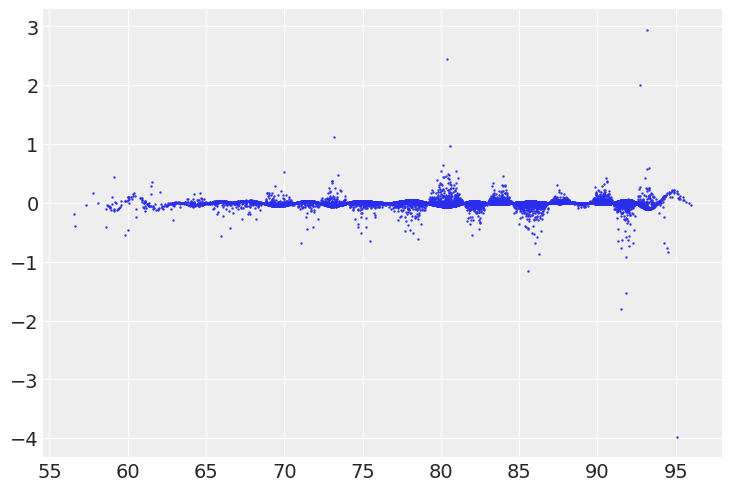

In [41]:
plt.scatter(_data['rh_mean_pop_weighted(1)'], pw, s=0.5)

---

In [14]:
df_compare = loo_compare(model_fits_folder, run_folders, p=None, num_knots=None, stat_name=['rh_mean_p(1)'])
df_compare['p'] = df_compare.index.str.extract(r'p=([\d.]+)', expand=False).astype(float)
df_compare['num_knots'] = df_compare.index.str.extract(r'__knots\((\d+)', expand=False).astype(int)
df_compare.reset_index(inplace=True, drop=True)
df_compare = df_compare[['p', 'num_knots', 'elpd_loo', 'dse', 'elpd_diff']]
# display(df_compare)
# df_compare.to_csv("comparerhm1.csv", index=False)
df_compare.head(50)

,p,num_knots,elpd_loo,dse,elpd_diff
0,12.5,5,-82388.014232,0.000000,0.000000
1,2.5,5,-82388.114288,0.116235,0.100056
2,10.0,5,-82388.170917,0.077732,0.156685
3,25.0,5,-82388.177764,0.052491,0.163532
4,1.0,5,-82388.187434,0.627161,0.173202
5,7.5,5,-82388.227522,0.064935,0.213290
6,16.0,5,-82388.329698,0.060540,0.315466
7,1000.0,5,-82388.346067,0.102705,0.331835
8,5.0,5,-82388.377157,0.107992,0.362925
9,20.0,5,-82388.559961,0.125568,0.545729


In [ ]:
df_compare = loo_compare(model_fits_folder, run_folders, p=[7.0, 10.0, 12.5, 15.0, 20.0], num_knots=[25, 30, 35, 40, 50, 60], std=[False])
df_compare['p'] = df_compare.index.str.extract(r'p=([\d.]+)', expand=False).astype(float)
df_compare['num_knots'] = df_compare.index.str.extract(r'__knots\((\d+)', expand=False).astype(int)
df_compare.reset_index(inplace=True, drop=True)
df_compare = df_compare[['p', 'num_knots', 'elpd_loo', 'dse', 'elpd_diff']]
display(df_compare)
df_compare.to_csv("best_p_num_knots_loo_comparison.csv", index=False)

,p,num_knots,elpd_loo,dse,elpd_diff
0,20.0,30,-82596.259534,0.000000,0.000000
1,15.0,30,-82596.481159,0.805990,0.221625
2,12.5,30,-82596.80556,1.390906,0.546026
3,10.0,30,-82597.152774,2.277091,0.893240
4,20.0,40,-82598.213296,2.311062,1.953762
5,15.0,40,-82598.462908,2.025580,2.203373
6,12.5,40,-82598.502355,2.228088,2.242821
7,15.0,50,-82598.88365,2.423895,2.624116
8,20.0,50,-82599.010408,2.748820,2.750874
9,7.0,30,-82599.104565,3.755355,2.845031


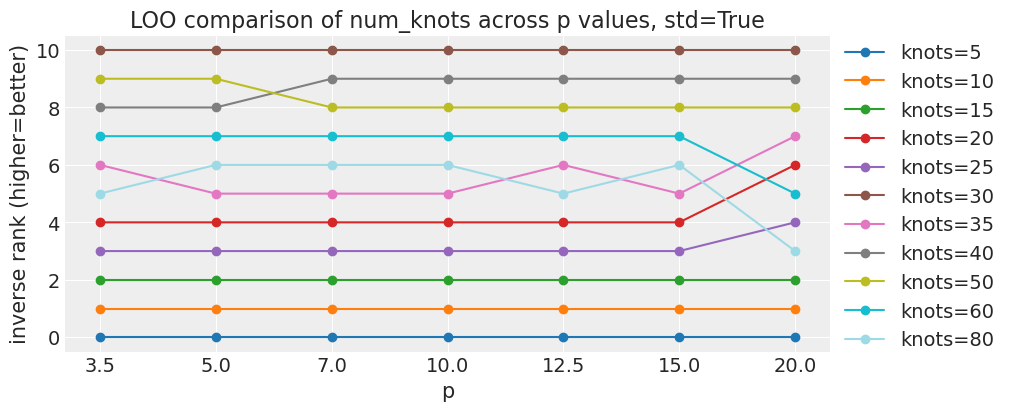

In [ ]:
p_vals = [3.5, 5.0, 7.0, 10.0, 12.5, 15.0, 20.0]
num_knots_list = [5, 10, 15, 20, 25, 30, 35, 40, 50, 60, 80]

colors = cm.tab20(np.linspace(0, 1, len(num_knots_list)))
fig, ax = plt.subplots(figsize=(10, 4))

for nk, color in zip(num_knots_list, colors):
    ranks = []
    for p_val in p_vals:
        df = loo_compare(model_fits_folder, run_folders, p=[p_val], num_knots=None, std=[True])
        df['num_knots'] = df.index.str.extract(r'__knots\((\d+)', expand=False).astype(int)
        df['inv_rank'] = len(df) - 1 - np.array(range(len(df)))
        row = df[df['num_knots'] == nk]
        ranks.append(row['inv_rank'].values[0] if len(row) else np.nan)
    ax.plot(np.arange(len(p_vals)), ranks, marker='o', label=f'knots={nk}', color=color)

ax.set_title("LOO comparison of num_knots across p values, std=True")
ax.set_xlabel('p')
ax.set_ylabel('inverse rank (higher=better)')
ax.set_xticks(np.arange(len(p_vals)))
ax.set_xticklabels(p_vals)
ax.legend(bbox_to_anchor=(1.01, 1), loc='upper left', borderaxespad=0)
plt.show()

---

In [ ]:
# Compare num_knots for different p values
p_vals = [0.1, 0.5, 1.0, 2.0, 3.5, 5.0, 7.0, 10.0]
fig, axes = plt.subplots(len(p_vals), 1, figsize=(8, 4 * len(p_vals)), sharex=False)

for ax, p_val in zip(axes, p_vals):
    df = loo_compare(model_fits_folder, run_folders, p=p_val, num_knots=None, std=False)
    df['num_knots'] = df.index.str.extract(r'__knots\((\d+)', expand=False).astype(int)
    df['rank'] = range(len(df))  # 0 = best
    df['inv_rank'] = len(df) - 1 - df['rank']  # higher = better

    id = np.argsort(df['num_knots'])
    ax.plot(df['num_knots'].iloc[id], df['inv_rank'].iloc[id], marker='o')
    ax.set_xticks(df['num_knots'].iloc[id])
    ax.set_xlabel('num_knots')
    ax.set_ylabel('inv_rank (higher=better)')
    ax.set_title(f'p={p_val}')

plt.show()